# Task 4 — Algorithmic Trading Strategies

This notebook designs and evaluates trading strategies and portfolio allocation on a multi-asset dataset. All validation uses walk-forward pseudo-OoS within the IS window — the true OoS is never examined.

**Structure:**
1. Data and IS window definition
2. Strategy framework and signal convention
3. Five strategies with mathematical definitions
4. In-sample performance (default parameters)
5. Parameter tuning via grid search
6. Overfitting — what it is and why it matters
7. Evaluation metrics
8. Walk-forward validation (pseudo-OoS)
9. Summary
10. Portfolio allocation — efficient frontier and walk-forward MVP

In [51]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

from config.plot_config import plot_config


output = plot_config() / "task4"
output.mkdir(exist_ok=True)




In [52]:
from helpers import DataAnalysis
analysis   = DataAnalysis.from_csv("spiff_data-2.csv").clean()
prices_raw = analysis.prices
prices_raw.head()

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026


## 1. Data and IS/OoS Split

### Data quality

The raw dataset has two problematic regions:

- **Days 0-1499**: heavy missingness across most assets -- too few observations for reliable rolling indicators.
- **Days 5000+**: a ~200-day trailing gap.

We restrict to **days 1500-4999** (3500 observations), the densest continuous block.

**Remaining gaps:** within this window there are 3 isolated single-day missing rows (around days 2836, 3430, and 4118). These correspond to non-trading days (e.g. market holidays). We **forward-fill** them: the price on a missing day is assumed unchanged from the prior close, contributing zero log-return on the next day. This is causal (looks only backward) and can safely be applied before the split.

### IS/OoS split

We split 70 / 30:

| Window | Purpose |
|--------|--------|
| **In-sample (IS)** -- first 70% | Strategy exploration, indicator choice, parameter selection |
| **Out-of-sample (OoS)** -- last 30% | Held out; examined exactly once at the end |

**Analysis discipline:** all strategy evaluation and parameter validation is performed on the IS window only, using walk-forward sub-folds as pseudo-OoS. The true OoS window is held out and not examined.


NaN cells before ffill: 21 (3*7=21 expected from placeholder values)
NaN cells after  ffill: 0

Clean window : day 1501 - 5256  (3756 obs)
IS           : day 1501 - 4504  (3004 obs, 80%)
OoS          : day 4505 - 5256  (752 obs, 20%)


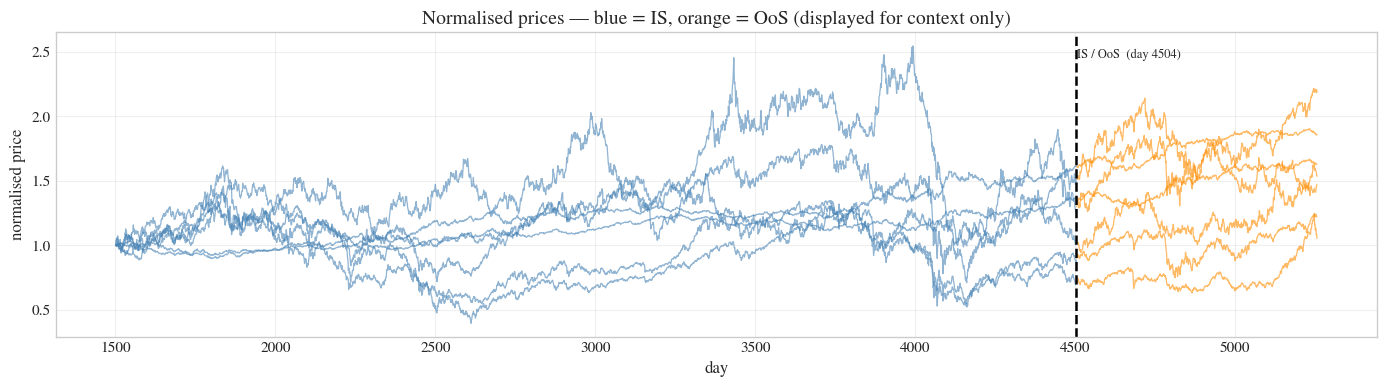

In [53]:
DATA_START = 1500
DATA_END   = 5256
IS_FRAC    = 0.8

prices_clean = prices_raw.iloc[DATA_START:DATA_END].copy()

n_before = prices_clean.isna().sum().sum()
prices_clean = prices_clean.ffill()
n_after  = prices_clean.isna().sum().sum()
print(f"NaN cells before ffill: {n_before} (3*7=21 expected from placeholder values)")
print(f"NaN cells after  ffill: {n_after}")
assert n_after == 0, "Unexpected NaNs remain after forward-fill"

n_clean   = len(prices_clean)
is_size   = int(n_clean * IS_FRAC)
prices_is  = prices_clean.iloc[:is_size]
prices_oos = prices_clean.iloc[is_size:]
split_day  = prices_is.index[-1]

print(f"\nClean window : day {prices_clean.index[0]} - {prices_clean.index[-1]}  ({n_clean} obs)")
print(f"IS           : day {prices_is.index[0]} - {split_day}  ({len(prices_is)} obs, {IS_FRAC:.0%})")
print(f"OoS          : day {prices_oos.index[0]} - {prices_oos.index[-1]}  ({len(prices_oos)} obs, {1-IS_FRAC:.0%})")

fig, ax = plt.subplots(figsize=(14, 4))
for col in prices_is.columns:
    base = prices_is[col].iloc[0]
    ax.plot(prices_is.index,  prices_is[col]  / base, color="steelblue",  alpha=0.6, linewidth=0.9)
    ax.plot(prices_oos.index, prices_oos[col] / base, color="darkorange", alpha=0.6, linewidth=0.9)
ax.axvline(split_day, color="black", linewidth=1.8, linestyle="--")
ax.text(split_day + 2, ax.get_ylim()[1] * 0.95, f"IS / OoS  (day {split_day})", fontsize=9, va="top")
ax.set_title("Normalised prices — blue = IS, orange = OoS (displayed for context only)")
ax.set_xlabel("day"); ax.set_ylabel("normalised price"); ax.grid(True, alpha=0.3)
asset_colors = dict(zip(prices_is.columns, plt.cm.tab10.colors))

plt.tight_layout()
plt.savefig(output / "is_oos_split.png", bbox_inches="tight")
plt.show()


## 2. Strategy Framework

### Long-only signals

All strategies produce a **binary position** for each asset each day:

| Signal | Position | Meaning |
|--------|----------|---------|
| **1** | Long | Buy or hold the asset |
| **0** | Flat | Sell / hold cash |

### One-day lag -- preventing look-ahead bias

Today's **position** must be set by **yesterday's** signal. If the indicator at close of day $t$ says "buy", we enter at the open of day $t+1$ and earn the return on day $t+1$:

$$\text{position}_t = s_{t-1}$$

where $s_t$ is the raw indicator computed from prices through day $t$. This is implemented by `.shift(1)` at the end of every signal function. Forgetting the shift creates **look-ahead bias** -- the strategy appears to trade on information it cannot yet have.

### The apply_signal function

`apply_signal` is **strategy-agnostic**. It accepts any position DataFrame and computes:

$$r^s_t = \text{position}_t \cdot \log\!\left(\frac{P_t}{P_{t-1}}\right)$$

Swapping in a new strategy only requires writing a new signal function -- `apply_signal`, `grid_search`, and `walk_forward` all work unchanged.


In [54]:
def apply_signal(signal: pd.DataFrame, prices: pd.DataFrame) -> dict:
    """
    Convert any position signal into strategy returns.

    Parameters
    ----------
    signal : DataFrame of positions {0, 1}, same index/columns as prices
    prices : DataFrame of price levels (log-returns computed internally)

    Returns
    -------
    dict with keys:
        signals    -- the input signal, unchanged
        returns    -- daily strategy log-returns (position_t x log_return_t)
        cumulative -- cumsum of returns (log-scale equity curve)
    """
    log_ret   = np.log(prices).diff()
    strat_ret = signal * log_ret
    return {
        "signals":    signal,
        "returns":    strat_ret,
        "cumulative": strat_ret.cumsum(),
    }


## 3. Strategies

### 3.1 Moving Average Crossover

**Rationale:** Prices in trending markets tend to persist. When the fast moving average crosses above the slow moving average, recent momentum is accelerating upward -- enter long. When the fast MA falls below the slow MA, the trend has reversed -- step aside.

**Mathematics:**

Let $P_t$ be the price on day $t$. Define rolling means with windows $f < s$:

$$\text{MA}_{f,t} = \frac{1}{f}\sum_{i=0}^{f-1} P_{t-i}, \qquad \text{MA}_{s,t} = \frac{1}{s}\sum_{i=0}^{s-1} P_{t-i}$$

Raw signal: $s_t = \mathbf{1}[\text{MA}_{f,t} > \text{MA}_{s,t}]$. Position: $\text{pos}_t = s_{t-1}$ (one-day lag).

**Parameters:** `fast` $f$, `slow` $s$.  
**Type:** Trend-following. Works well in trending regimes; suffers whipsaws in choppy sideways markets.


In [55]:
def ma_crossover_signal(prices: pd.DataFrame, fast: int, slow: int) -> pd.DataFrame:
    """
    MA crossover long-only position signal.
    Returns 1 (long) when fast MA > slow MA yesterday, else 0 (flat).
    """
    fast_ma = prices.rolling(fast).mean()
    slow_ma = prices.rolling(slow).mean()
    return (fast_ma > slow_ma).astype(float).shift(1)


### 3.4 Template -- Adding a New Strategy

Copy this template to implement a fourth strategy. The only contract: input is `prices`, output is a DataFrame of the same shape with values in {0, 1}, last operation is `.shift(1)`.

```python
def my_strategy_signal(
    prices: pd.DataFrame,
    param1: int = 10,
    param2: float = 1.0,
) -> pd.DataFrame:
    # 1. Compute your indicator using only past prices (no future look-ahead)
    indicator = ...

    # 2. Define entry and exit rules
    raw = pd.DataFrame(np.nan, index=prices.index, columns=prices.columns)
    raw[<entry condition>] = 1.0   # go long
    raw[<exit condition>]  = 0.0   # go flat

    # 3. Fill neutral zone and apply one-day lag
    # Hold-until-opposite style (ffill until opposite signal):
    #     return raw.ffill().fillna(0.0).shift(1)
    # Clean signal at every step (MA crossover style):
    #     return raw.fillna(0.0).shift(1)
```

Once defined, plug into `apply_signal`, `grid_search`, and `walk_forward` with no other changes.


### 3.5 Pairs Strategies

**Rationale:** If two assets are co-integrated — their log-price spread is stationary — deviations from the long-run equilibrium are temporary and exploitable via mean-reversion. We test two independent pairs:

- **gurkor / water** (`Pairs g/w`)
- **guitars / slingshots** (`Pairs gu/sl`)

**Spread definition:**
$$s_t = \log(A_t) - \log(B_t)$$

**Rolling z-score:**
$$z_t = \frac{s_t - \hat{\mu}_w}{\hat{\sigma}_w}$$

**Position rules** (long-only — we never short either leg):

| Condition | Asset A | Asset B | Interpretation |
|-----------|---------|---------|----------------|
| $z_t < -z_{\text{entry}}$ | **1** | 0 | A cheap relative to B |
| $z_t > +z_{\text{entry}}$ | 0 | **1** | B cheap relative to A |
| $\|z_t\| < z_{\text{exit}}$ | 0 | 0 | spread has reverted — close |
| otherwise | hold | hold | neutral zone |

**Parameters:** `window` (spread lookback), `entry_z` (entry threshold), `exit_z` (exit threshold, fixed at 0.5).

> **Note on portfolio Sharpe:** Each pair trades only 2 of 7 assets; the remaining 5 contribute zero return. The constant dilution factor cancels in the Sharpe ratio, so figures remain directly comparable with the single-asset strategies.


In [56]:
def pairs_signal(
    prices: pd.DataFrame,
    asset1: str,
    asset2: str,
    window: int    = 60,
    entry_z: float = 1.5,
    exit_z: float  = 0.5,
) -> pd.DataFrame:
    """
    Generic long-only pairs strategy.

    spread = log(asset1) - log(asset2); enter when |z| > entry_z,
    exit when |z| < exit_z, hold in the neutral zone in between.
    """
    spread = np.log(prices[asset1]) - np.log(prices[asset2])
    rm     = spread.rolling(window).mean()
    rs     = spread.rolling(window).std()
    z      = (spread - rm) / rs

    raw1 = pd.Series(np.nan, index=prices.index)
    raw2 = pd.Series(np.nan, index=prices.index)

    raw1[z.lt(-entry_z)] = 1.0   # asset1 cheap
    raw2[z.lt(-entry_z)] = 0.0
    raw1[z.gt(entry_z)]  = 0.0   # asset2 cheap
    raw2[z.gt(entry_z)]  = 1.0
    raw1[z.abs().lt(exit_z)] = 0.0  # spread reverted
    raw2[z.abs().lt(exit_z)] = 0.0

    raw1 = raw1.ffill().fillna(0.0)
    raw2 = raw2.ffill().fillna(0.0)

    out = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    out[asset1] = raw1
    out[asset2] = raw2
    return out.shift(1)


def gw_signal(prices: pd.DataFrame, window: int = 60,
              entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Pairs wrapper: gurkor / water."""
    return pairs_signal(prices, "gurkor", "water", window, entry_z, exit_z)


def gusl_signal(prices: pd.DataFrame, window: int = 60,
                entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Pairs wrapper: guitars / slingshots."""
    return pairs_signal(prices, "guitars", "slingshots", window, entry_z, exit_z)


def ws_signal(prices: pd.DataFrame, window: int = 60,
             entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Pairs wrapper: water / slingshots."""
    return pairs_signal(prices, "water", "slingshots", window, entry_z, exit_z)





In [57]:
def buy_and_hold_signal(prices: pd.DataFrame) -> pd.DataFrame:
    """Always long — baseline buy-and-hold. No parameters to tune."""
    return pd.DataFrame(1.0, index=prices.index, columns=prices.columns)

### 3.6 Long-Short Pairs Strategy

The long-only pairs strategy only captures one side of the spread: when asset A is cheap relative to B, we go long A and wait. The **long-short** variant is fully market-neutral: it *simultaneously* goes long the cheap leg and short the expensive leg.

**Position rules** — spread $z_t = (s_t - \hat{\mu}_w)/\hat{\sigma}_w$:

| Condition | Asset A | Asset B | Interpretation |
|-----------|---------|---------|----------------|
| $z_t < -z_{\text{entry}}$ | **+1** | **-1** | A cheap: long A, short B |
| $z_t > +z_{\text{entry}}$ | **-1** | **+1** | B cheap: short A, long B |
| $\|z_t\| < z_{\text{exit}}$ | 0 | 0 | Spread reverted — flat both |
| otherwise | hold | hold | Neutral zone |

Positions $\in \{-1, 0, +1\}$. `apply_signal` multiplies position by log-return, so $-1$ correctly earns the negative of the asset's return (short profit). Parameters are identical to the long-only version: `window`, `entry_z`, `exit_z`.

> **Key difference from long-only:** both legs are always active when in a trade (one long, one short), making the strategy self-financing and dollar-neutral.

In [58]:
def pairs_ls_signal(
    prices: pd.DataFrame,
    asset1: str,
    asset2: str,
    window: int    = 60,
    entry_z: float = 1.5,
    exit_z: float  = 0.5,
) -> pd.DataFrame:
    """
    Long-short pairs strategy: positions in {-1, 0, +1}.
    z < -entry_z  -> long asset1, short asset2
    z > +entry_z  -> short asset1, long asset2
    |z| < exit_z  -> flat both
    """
    spread = np.log(prices[asset1]) - np.log(prices[asset2])
    rm     = spread.rolling(window).mean()
    rs     = spread.rolling(window).std()
    z      = (spread - rm) / rs

    raw1 = pd.Series(np.nan, index=prices.index)
    raw2 = pd.Series(np.nan, index=prices.index)

    raw1[z.lt(-entry_z)] =  1.0   # asset1 cheap: long A, short B
    raw2[z.lt(-entry_z)] = -1.0
    raw1[z.gt(entry_z)]  = -1.0   # asset2 cheap: short A, long B
    raw2[z.gt(entry_z)]  =  1.0
    raw1[z.abs().lt(exit_z)] = 0.0  # spread reverted
    raw2[z.abs().lt(exit_z)] = 0.0

    raw1 = raw1.ffill().fillna(0.0)
    raw2 = raw2.ffill().fillna(0.0)

    out = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    out[asset1] = raw1
    out[asset2] = raw2
    return out.shift(1)


def gw_ls_signal(prices: pd.DataFrame, window: int = 60,
                 entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Long-short pairs wrapper: gurkor / water."""
    return pairs_ls_signal(prices, "gurkor", "water", window, entry_z, exit_z)


def gusl_ls_signal(prices: pd.DataFrame, window: int = 60,
                   entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Long-short pairs wrapper: guitars / slingshots."""
    return pairs_ls_signal(prices, "guitars", "slingshots", window, entry_z, exit_z)


def ws_ls_signal(prices: pd.DataFrame, window: int = 60,
                entry_z: float = 1.5, exit_z: float = 0.5) -> pd.DataFrame:
    """Long-short pairs wrapper: water / slingshots."""
    return pairs_ls_signal(prices, "water", "slingshots", window, entry_z, exit_z)


## 4. In-Sample Performance (Default Parameters)

Before tuning anything, we run all strategies with **default parameters** on IS data.

1. **Sanity check** — does the strategy trade at all? Are signals sensible?
2. **Per-asset IS return** — a heatmap of the final cumulative IS log-return for every (asset, strategy) pair. Each cell is evaluated independently; no averaging across assets.

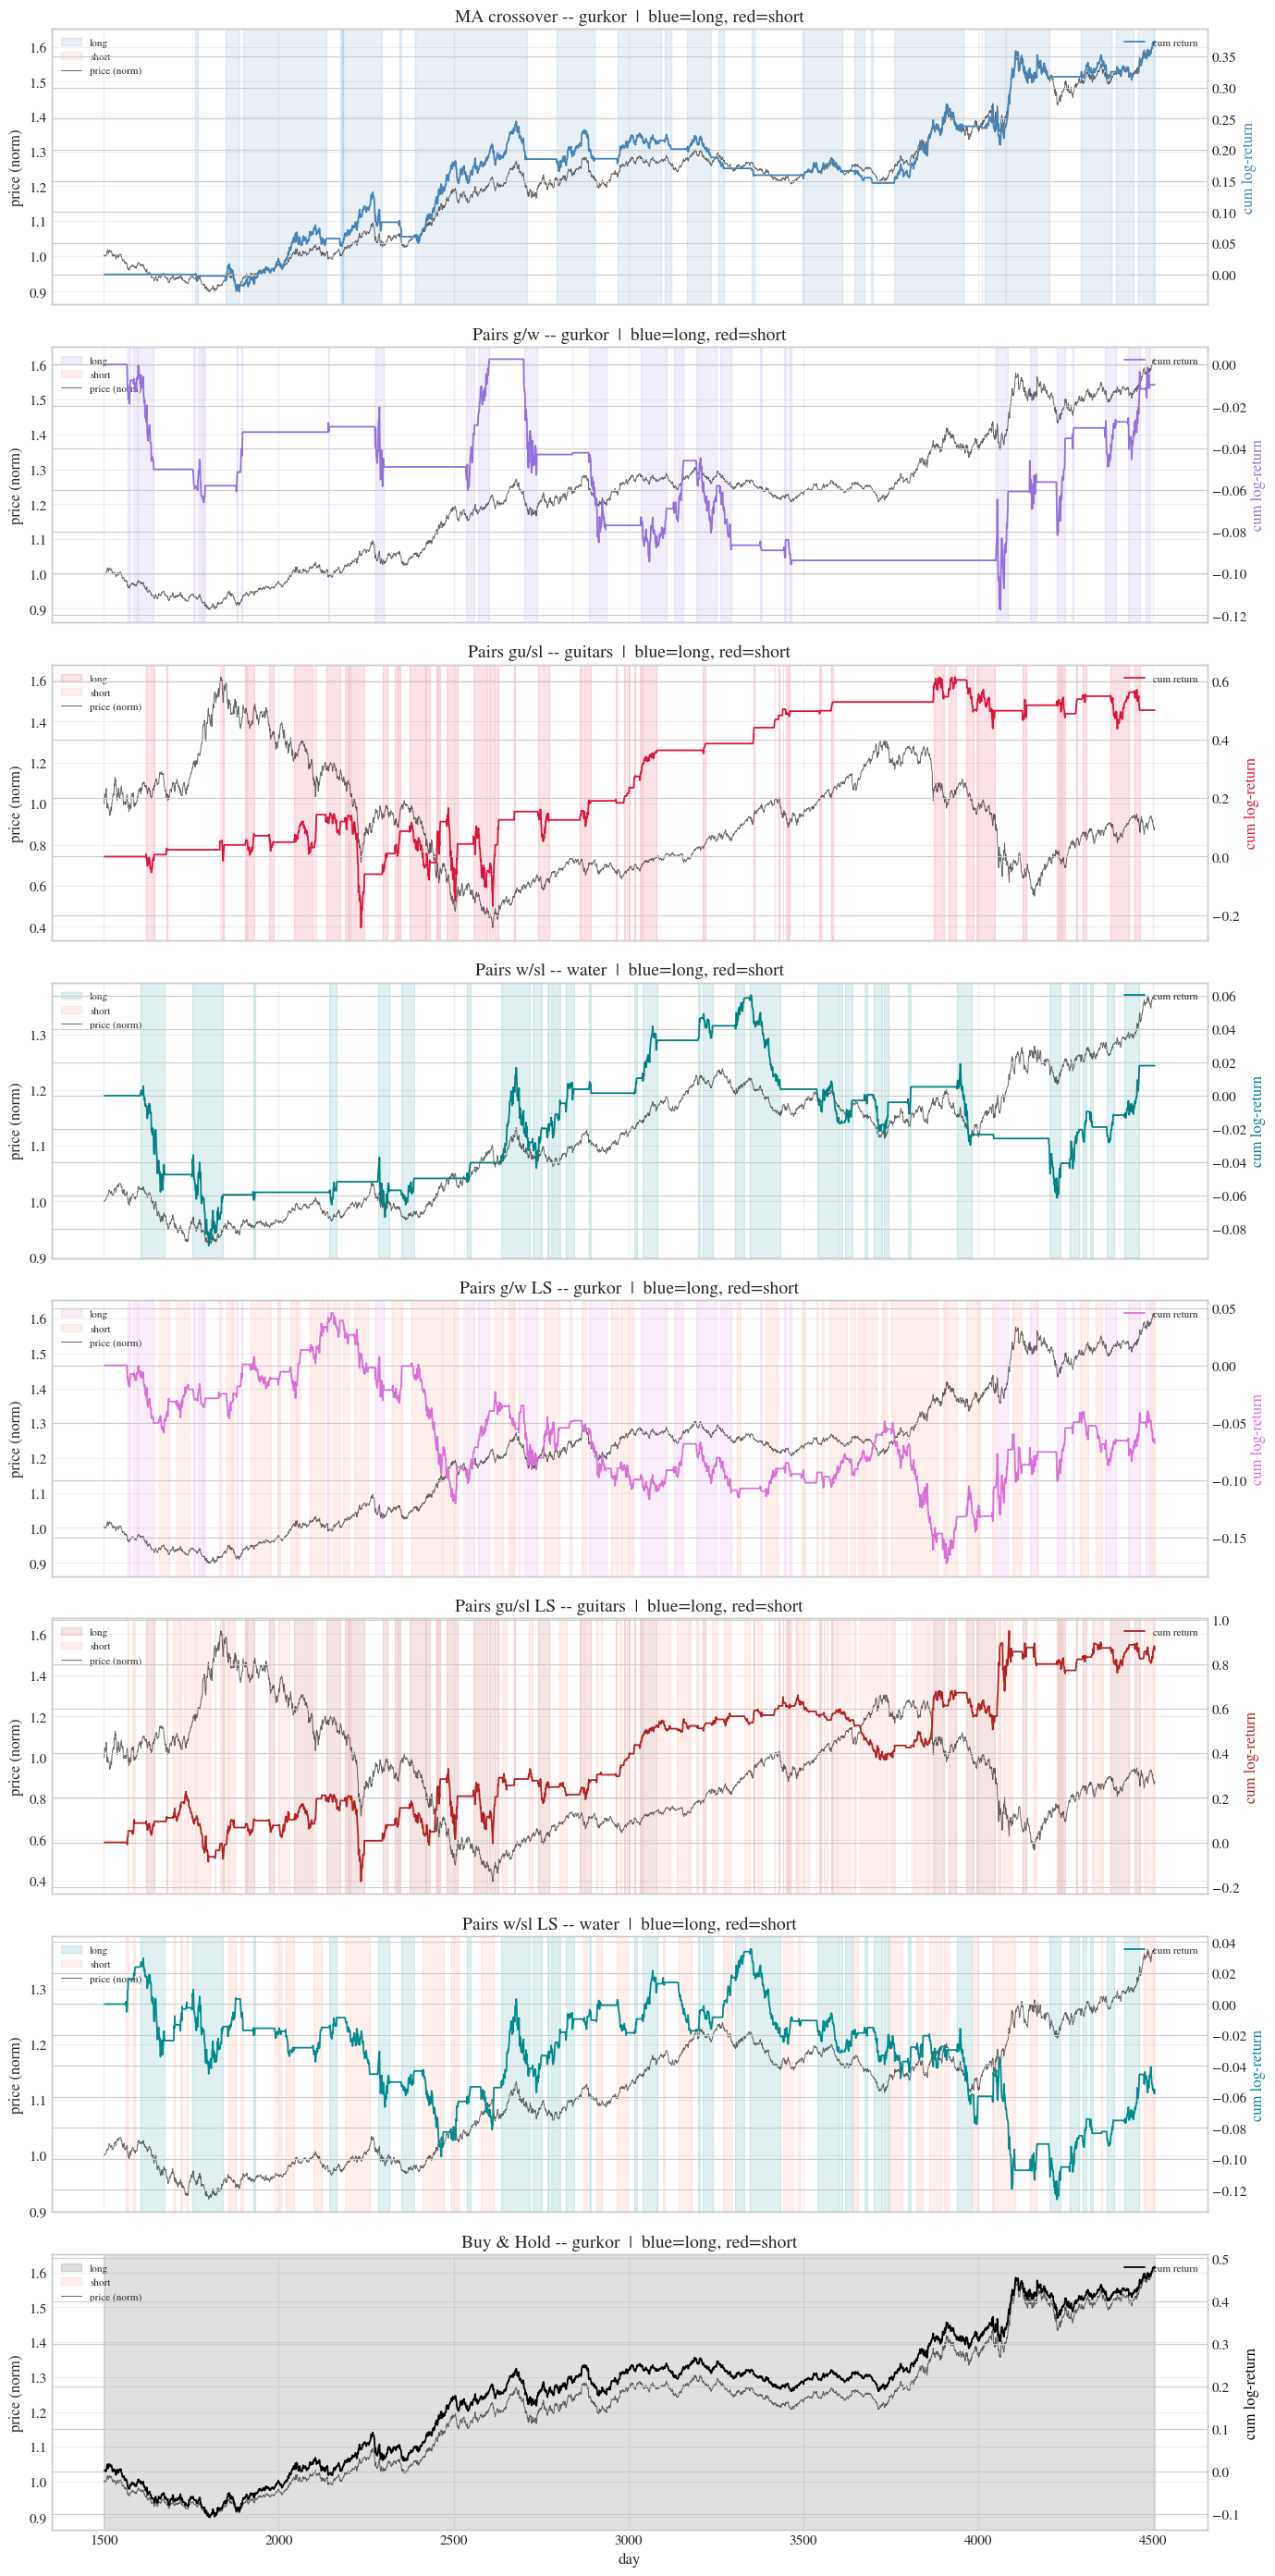

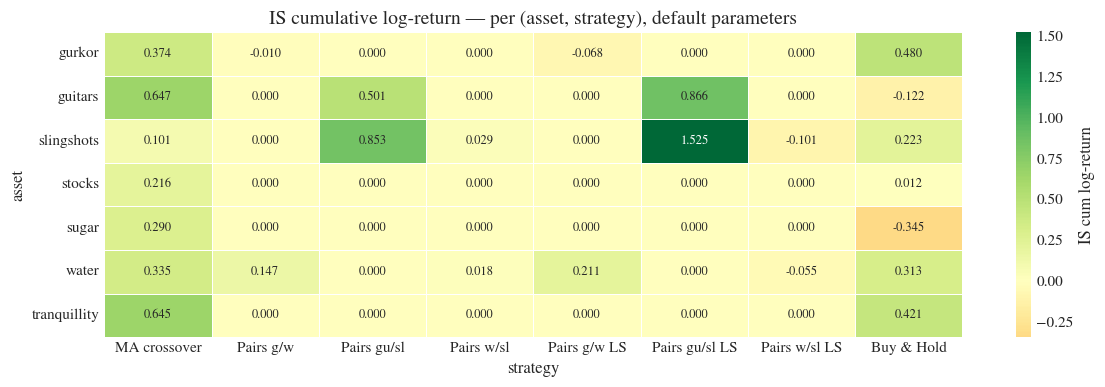

IS performance — equal-weighted portfolio (default parameters):


,ann_return,cagr,ann_vol,sharpe,max_drawdown,avg_drawdown,calmar,sortino
Strategy,,,,,,,,
MA crossover,4.53,4.63,6.91,0.221,-0.144,-0.056,0.322,0.845
Pairs g/w,0.24,0.24,0.78,-3.556,-0.024,-0.011,0.101,0.330
Pairs gu/sl,2.35,2.38,3.65,-0.178,-0.059,-0.011,0.405,0.571
Pairs w/sl,0.08,0.08,3.24,-0.901,-0.079,-0.026,0.010,0.021
Pairs g/w LS,0.25,0.25,0.71,-3.862,-0.012,-0.004,0.216,0.420
Pairs gu/sl LS,4.15,4.24,3.30,0.349,-0.030,-0.005,1.426,1.322
Pairs w/sl LS,-0.27,-0.27,3.88,-0.843,-0.087,-0.040,-0.031,-0.073
Buy & Hold,1.71,1.72,11.58,-0.112,-0.375,-0.118,0.046,0.207


<Figure size 700x400 with 0 Axes>

In [59]:
RF                  = 0.03   # annual risk-free rate: 3 % long-term bond (per project specification)
FAST, SLOW          = 20, 120
PAIRS_WINDOW        = 60; PAIRS_ENTRY_Z = 1.5; PAIRS_EXIT_Z = 0.5

STRAT_COLORS = {
    "MA crossover":    "steelblue",
    "Pairs g/w":       "mediumpurple",
    "Pairs gu/sl":     "crimson",
    "Pairs w/sl":      "teal",
    "Pairs g/w LS":    "orchid",
    "Pairs gu/sl LS":  "firebrick",
    "Pairs w/sl LS":   "darkcyan",
    "Buy & Hold":      "black",
}

res_ma_def      = apply_signal(ma_crossover_signal(prices_is, fast=FAST, slow=SLOW), prices_is)
res_gw_def      = apply_signal(gw_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_gusl_def    = apply_signal(gusl_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_gw_ls_def   = apply_signal(gw_ls_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_gusl_ls_def = apply_signal(gusl_ls_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_ws_def      = apply_signal(ws_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_ws_ls_def   = apply_signal(ws_ls_signal(prices_is,
                               window=PAIRS_WINDOW, entry_z=PAIRS_ENTRY_Z, exit_z=PAIRS_EXIT_Z), prices_is)
res_bh_def      = apply_signal(buy_and_hold_signal(prices_is), prices_is)

default_specs = [
    ("MA crossover",   res_ma_def,      "steelblue"),
    ("Pairs g/w",      res_gw_def,      "mediumpurple"),
    ("Pairs gu/sl",    res_gusl_def,    "crimson"),
    ("Pairs w/sl",     res_ws_def,      "teal"),
    ("Pairs g/w LS",   res_gw_ls_def,   "orchid"),
    ("Pairs gu/sl LS", res_gusl_ls_def, "firebrick"),
    ("Pairs w/sl LS",  res_ws_ls_def,   "darkcyan"),
    ("Buy & Hold",     res_bh_def,      "black"),
]

# Show gurkor for all strategies (pairs g/w: gurkor leg; pairs gu/sl: guitars leg)
asset = "gurkor"
col_map = {
    "Pairs gu/sl":    "guitars",
    "Pairs gu/sl LS": "guitars",
    "Pairs w/sl":     "water",
    "Pairs w/sl LS":  "water",
}
n_strats = len(default_specs)
fig, axes = plt.subplots(n_strats, 1, figsize=(14, 3.5 * n_strats), sharex=True)
for ax, (label, res, c) in zip(axes, default_specs):
    col = col_map.get(label, asset)
    sig        = res["signals"][col]
    cum        = res["cumulative"][col]
    price_norm = prices_is[col] / prices_is[col].iloc[0]
    ax.fill_between(sig.index, 0, 1, where=(sig > 0), alpha=0.12, color=c,
                    transform=ax.get_xaxis_transform(), label="long")
    ax.fill_between(sig.index, 0, 1, where=(sig < 0), alpha=0.12, color="salmon",
                    transform=ax.get_xaxis_transform(), label="short")
    ax.plot(prices_is.index, price_norm, color="black", linewidth=0.7, alpha=0.6, label="price (norm)")
    ax2 = ax.twinx()
    ax2.plot(cum.index, cum.values, color=c, linewidth=1.3, label="cum return")
    ax.set_title(f"{label} -- {col}  |  blue=long, red=short")
    ax.set_ylabel("price (norm)"); ax2.set_ylabel("cum log-return", color=c)
    ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("day")
plt.tight_layout()
plt.savefig(output / "is_default_signals.png", bbox_inches="tight")
plt.show()

# per (asset, strategy) IS cumulative log-return — default params
cum_ret = {}
for label, res, _ in default_specs:
    cum_ret[label] = {col: res["cumulative"][col].iloc[-1] for col in prices_is.columns}
cum_df = pd.DataFrame(cum_ret)

fig, ax = plt.subplots(figsize=(12, 4))
annot  = cum_df.apply(lambda col: col.map(lambda x: f"{x:.3f}" if not pd.isna(x) else ""))
sns.heatmap(cum_df, annot=annot, fmt="", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "IS cum log-return"},
            annot_kws={"size": 9})
ax.set_title("IS cumulative log-return — per (asset, strategy), default parameters")
ax.set_xlabel("strategy"); ax.set_ylabel("asset")
plt.tight_layout()
plt.savefig(output / "is_default_per_asset.png", bbox_inches="tight")
plt.show()


# ── IS metrics table — equal-weighted portfolio, default parameters ───────────
bh_is_ret = res_bh_def["returns"].mean(axis=1)
rows = []
for label, res, _ in default_specs:
    port_ret = res["returns"].mean(axis=1)
    m = backtest_metrics(port_ret, bh_ret=bh_is_ret)
    rows.append({"Strategy": label, **{k: round(v, 3) if isinstance(v, float) else v for k, v in m.items()}})

is_metrics_df = pd.DataFrame(rows).set_index("Strategy")
print("IS performance — equal-weighted portfolio (default parameters):")
display(is_metrics_df[["ann_return", "cagr", "ann_vol", "sharpe", "max_drawdown", "avg_drawdown", "calmar", "sortino"]])
plt.savefig(output / "is_default_metrics.png", bbox_inches="tight")

In [60]:
def grid_search(
    prices_ref: pd.DataFrame,
    signal_fn,
    param_grid: list[dict],
    ann: int = 365,
) -> pd.DataFrame:
    """Strategy-agnostic IS grid search. Optimises equal-weight portfolio Sharpe."""
    rows = []
    for params in param_grid:
        sig  = signal_fn(prices_ref, **params)
        res  = apply_signal(sig, prices_ref)
        port = res["returns"].mean(axis=1).dropna()
        vol  = port.std() * np.sqrt(ann)
        sr   = (port.mean() * ann - RF) / vol if vol > 0 else np.nan
        rows.append({**params, "sharpe": sr})
    return pd.DataFrame(rows)


def per_asset_grid_search(
    prices_ref: pd.DataFrame,
    signal_fn,
    param_grid: list[dict],
    ann: int = 365,
) -> dict[str, dict]:
    """
    Grid search optimised independently per asset.

    Each asset's parameters maximise that asset's own IS Sharpe ratio.
    Returns {asset_name: best_params_dict}.
    """
    log_ret        = np.log(prices_ref).diff()
    best_per_asset = {}
    for asset in prices_ref.columns:
        rows = []
        for params in param_grid:
            sig = signal_fn(prices_ref, **params)[asset]
            ret = (sig * log_ret[asset]).dropna()
            vol = ret.std() * np.sqrt(ann)
            sr  = (ret.mean() * ann - RF) / vol if vol > 0 else np.nan
            rows.append({**params, "sharpe": sr})
        orig_types = {k: type(v) for k, v in param_grid[0].items()}
        df   = pd.DataFrame(rows)
        best = df.loc[df["sharpe"].idxmax()] if df["sharpe"].notna().any() else df.iloc[0]
        best_per_asset[asset] = {k: orig_types[k](v) for k, v in best.items() if k != "sharpe"}
    return best_per_asset


def build_per_asset_signal(
    prices: pd.DataFrame,
    signal_fn,
    best_params: dict[str, dict],
) -> pd.DataFrame:
    """Assemble a signal DataFrame using each asset's own best parameters."""
    return pd.DataFrame({
        asset: signal_fn(prices, **params)[asset]
        for asset, params in best_params.items()
    })

## 6. Overfitting and Why OoS Data Matters

### What is overfitting?

Overfitting occurs when a model learns the specific patterns of the training data so well that it fails to generalise to new data. In trading, the "model" is a set of parameter choices; the "training data" is the IS period.

**The core problem:** given enough parameters to search over, we can always find *some* combination that looks excellent on IS data -- not because it captures a genuine market inefficiency, but because it was selected specifically because it happened to work on that historical window.

Analogy: if you flip a coin 100 times, you can find a subsequence where heads appeared 80% of the time. Finding it does not mean the coin is biased -- you just searched until you found something that looked interesting.

### Why IS Sharpe is a biased estimate

Suppose you evaluate $K$ parameter combinations and pick the one with the highest IS Sharpe. Under the null hypothesis (all strategies are pure noise with true Sharpe = 0), the expected maximum Sharpe across $K$ trials satisfies:

$$E\!\left[\max_{k=1}^{K} S_k\right] \approx \sqrt{2 \log K}$$

With $K = 24$ combinations (MA grid), the expected maximum noise Sharpe is $\approx \sqrt{2\log 24} \approx 2.4$. These are **purely from selection**, with zero true signal. The larger the grid, the more inflated the IS optimum becomes.

### Signs of overfitting to watch for

| Warning sign | Interpretation |
|-------------|---------------|
| IS Sharpe much greater than OoS Sharpe | Strong overfitting to IS window |
| Best params at edge of grid | Optimiser fitting noise; no interior optimum |
| Params change dramatically fold-to-fold | No stable relationship with market features |
| Performance driven by 1-2 assets or folds | Luck, not edge |

### Out-of-sample data as the antidote

The OoS window was never used in any decision. Because no parameters were chosen based on OoS data, OoS performance is an **unbiased estimate** of how the strategy would have performed if deployed at that date.

**The golden rule:** the OoS window must be used exactly once. If you examine OoS results and then adjust the strategy in response, it becomes a second IS window -- you are now fitting to it, and any further OoS test requires completely fresh data.


## 7. Evaluation Metrics

Before examining OoS results, we define exactly how performance is measured. Max drawdown is computed on actual equity (not cumulative log-return) to correctly represent the worst peak-to-trough loss.

| Metric | Definition | What it measures |
|--------|-----------|------------------|
| **Total log return** | Sum of log-returns | Total compounded gain |
| **Annualised return** | 365 * mean daily return | Average daily return scaled to one year |
| **Annualised volatility** | sqrt(365) * std(daily returns) | Risk |
| **Sharpe ratio** | ann. return / ann. vol. | Return per unit of total risk |
| **Sortino ratio** | ann. return / downside vol. | Return per unit of downside risk only |
| **Max drawdown** | min(equity / peak_equity - 1) | Worst peak-to-trough equity loss |
| **Calmar ratio** | ann. return / abs(max DD) | Return per unit of worst drawdown |
| **Hit rate** | fraction of days with positive return | How often the strategy earns anything |
| **Profit factor** | sum(wins) / abs(sum(losses)) | Gross profit vs gross loss; >1 = profitable overall |
| **Avg win / Avg loss** | mean(positive days) / abs(mean(negative days)) | Size of a typical win vs a typical loss |
| **Win/loss ratio** | avg_win / abs(avg_loss) | Reward-to-risk per trade |
| **Max consec. wins/losses** | longest run of positive / negative days | Streak risk — how long bad runs last |
| **Avg hold (days)** | days in position / number of entries | Average trade duration |
| **Trades per year** | entries per year = n_trades / (n_days / 365) | Trading frequency |
| **Win/loss ratio** | avg_win / |avg_loss| | Reward-to-risk per active day |
| **Max consec. wins/losses** | longest run of positive / negative days | Streak risk |


In [61]:
def backtest_metrics(strat_ret: pd.Series, bh_ret: pd.Series | None = None, ann: int = 365) -> dict:
    """
    Comprehensive single-series backtest metrics.
    Max drawdown uses actual equity exp(cumulative log-return), not raw log-return.
    """
    sr = strat_ret.dropna()
    if sr.empty:
        return {}

    cum          = sr.cumsum()
    n_days       = len(sr)
    ann_ret      = sr.mean() * ann
    cagr         = (np.exp(cum.iloc[-1])) ** (ann / n_days) - 1
    ann_vol      = sr.std() * np.sqrt(ann)
    sharpe       = (ann_ret - RF) / ann_vol if ann_vol > 0 else np.nan

    neg          = sr[sr < 0]
    downside_vol = neg.std() * np.sqrt(ann) if len(neg) > 1 else np.nan
    sortino      = ann_ret / downside_vol if (downside_vol and downside_vol > 0) else np.nan

    # Prepend 0 so equity starts at 1.0 — captures losses from day 1
    cum_padded   = pd.concat([pd.Series([0.0], index=[cum.index[0] - 1]), cum])
    equity       = np.exp(cum_padded)
    drawdown     = (equity / equity.cummax() - 1).iloc[1:]  # drop artificial start
    max_dd       = drawdown.min()
    avg_dd       = drawdown[drawdown < 0].mean() if (drawdown < 0).any() else 0.0
    calmar       = cagr / abs(max_dd) if max_dd < 0 else np.nan

    signal   = (sr != 0).astype(int)
    n_trades = int(((signal == 1) & (signal.shift(1) == 0)).sum())
    avg_hold = (signal.sum() / n_trades) if n_trades > 0 else np.nan
    trades_per_year = (n_trades / (n_days / ann)) if n_days > 0 and n_trades > 0 else np.nan

    wins   = sr[sr > 0]
    losses = sr[sr < 0]
    profit_factor  = (wins.sum() / abs(losses.sum())) if len(losses) > 0 and losses.sum() != 0 else np.nan
    avg_win        = float(wins.mean())   if len(wins)   > 0 else np.nan
    avg_loss       = float(losses.mean()) if len(losses) > 0 else np.nan
    win_loss_ratio = (avg_win / abs(avg_loss)) if (not np.isnan(avg_loss) and avg_loss != 0) else np.nan

    signs = np.sign(sr.values)
    def _max_streak(s, target):
        best = cur = 0
        for v in s:
            if v == target:
                cur += 1; best = max(best, cur)
            else:
                cur = 0
        return int(best)
    max_consec_wins   = _max_streak(signs,  1)
    max_consec_losses = _max_streak(signs, -1)

    out = {
        "total_log_ret":     round(cum.iloc[-1], 4),
        "ann_return":        round(ann_ret*100, 2),
        "cagr":              round(cagr*100, 2),
        "ann_vol":           round(ann_vol*100, 2),
        "sharpe":            round(sharpe, 3),
        "sortino":           round(sortino, 3) if not np.isnan(sortino) else np.nan,
        "max_drawdown":      round(max_dd, 4),
        "avg_drawdown":      round(avg_dd, 4),
        "calmar":            round(calmar, 3) if (calmar and not np.isnan(calmar)) else np.nan,
        "hit_rate":          round((sr > 0).mean(), 3),
        "profit_factor":     round(profit_factor, 3) if not np.isnan(profit_factor) else np.nan,
        "avg_win":           round(avg_win, 5) if not np.isnan(avg_win) else np.nan,
        "avg_loss":          round(avg_loss, 5) if not np.isnan(avg_loss) else np.nan,
        "win_loss_ratio":    round(win_loss_ratio, 3) if not np.isnan(win_loss_ratio) else np.nan,
        "max_consec_wins":   max_consec_wins,
        "max_consec_losses": max_consec_losses,
        "n_trades":          int(n_trades),
        "avg_hold_days":     round(avg_hold, 1) if avg_hold and not np.isnan(avg_hold) else np.nan,
        "trades_per_year":   round(trades_per_year, 1) if not np.isnan(trades_per_year) else np.nan,
    }
    if bh_ret is not None:
        bh        = bh_ret.dropna()
        bh_cum    = bh.cumsum()
        bh_ann    = bh.mean() * ann
        bh_cagr   = (np.exp(bh_cum.iloc[-1])) ** (ann / len(bh)) - 1
        bh_vol    = bh.std() * np.sqrt(ann)
        bh_sharpe = (bh_ann - RF) / bh_vol if bh_vol > 0 else np.nan
        out["bh_ann_return"] = round(bh_ann, 4)
        out["bh_cagr"]       = round(bh_cagr, 4)
        out["bh_sharpe"]     = round(bh_sharpe, 3)
        out["excess_ret"]    = round(cagr - bh_cagr, 4)
        out["excess_riskfree"] = round(cagr - RF, 4)
    return out

## 8. Walk-Forward Validation

All performance evaluation is done via **walk-forward pseudo-OoS**: parameters are selected on an expanding IS window, then tested on the immediately following sub-fold. The true OoS window is set aside and never examined.

| Sub-section | Question answered |
|-------------|-----------------|
| **8.1 Walk-forward** | Do strategies produce positive pseudo-OoS returns consistently across sub-folds? |
| **8.1.1 Parameter stability** | Do the chosen parameters change dramatically fold-to-fold? |
| **8.2 Bootstrap significance** | Is the walk-forward Sharpe statistically distinguishable from zero, after correcting for multiple testing across all (asset, strategy) pairs? |
| **8.3 Per-asset breakdown** | Does performance hold consistently across all assets, or is it driven by one lucky asset? |

### 8.1 Walk-Forward Validation

Walk-forward repeats IS parameter optimisation across 5 non-overlapping sub-folds of the full dataset using a **fixed-size sliding IS window**. Each training window has the same length (`train_size` days); the window slides forward by one fold at a time. Crucially, none of these folds use the main 70/30 OoS window — this is purely an IS robustness check.

```
[IS1] | OoS1
   [IS2] | OoS2     (same width, shifted forward)
      [IS3] | OoS3
         [IS4] | OoS4
            [IS5] | OoS5
```

**What to look for:**
- **OoS Sharpe consistency** -- positive in all folds, or driven by 1-2 lucky periods?
- **Parameter stability** -- do the best parameters change dramatically fold-to-fold? High instability suggests noise.
- **Stitched equity curve** -- the concatenated OoS returns across folds. A steadily rising curve indicates genuine positive expectation across time.


In [62]:
FAST_GRID = [10, 15, 20, 30]
SLOW_GRID = [20, 30, 40, 60, 80, 120, 150, 200, 252]
MA_PARAM_GRID = [{"fast": f, "slow": s} for f in FAST_GRID for s in SLOW_GRID if f < s]
PAIRS_PARAM_GRID = [
    {"window": w, "entry_z": e, "exit_z": 0.5}
    for w in [2, 5, 10, 30, 60]
    for e in [0.0625,0.125,0.25, 0.5, 1.0, 1.5, 2.0,2.5,3,4]
]

IS_SIZE  = 500   # days per IS window
OOS_SIZE = 100   # days per OoS window
WF_STEP  = 100   # days to slide forward each fold

def walk_forward(
    prices: pd.DataFrame,
    signal_fn,
    param_grid: list[dict],
    is_size: int = IS_SIZE,
    oos_size: int = OOS_SIZE,
    step: int = WF_STEP,
    ann: int = 365,
    per_asset: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Sliding-window walk-forward. Fixed IS and OoS windows, slides forward by step each fold.

    Fold k: IS = [k*step, k*step+is_size), OoS = [k*step+is_size, k*step+is_size+oos_size)
    per_asset=True  -- each fold runs per_asset_grid_search; each asset gets its own params.
    per_asset=False -- each fold runs grid_search; one shared param set for all assets.
    """
    n = len(prices)
    oos_chunks, fold_rows = [], []

    fold = 0
    while True:
        is_start = fold * step
        is_end   = is_start + is_size
        oos_end  = is_end + oos_size
        if oos_end > n:
            break
        p_is     = prices.iloc[is_start:is_end]
        p_oos    = prices.iloc[is_end:oos_end]
        combined = pd.concat([p_is, p_oos])

        if per_asset:
            best_p  = per_asset_grid_search(p_is, signal_fn, param_grid, ann=ann)
            sig     = build_per_asset_signal(combined, signal_fn, best_p)
            is_rets = apply_signal(
                build_per_asset_signal(p_is, signal_fn, best_p), p_is
            )["returns"]
            per_sr = []
            for col in is_rets.columns:
                r = is_rets[col].dropna()
                if (r == 0).all(): continue
                v = r.std() * np.sqrt(ann)
                per_sr.append(r.mean() * ann / v if v > 0 else np.nan)
            is_sr = float(np.nanmean(per_sr)) if per_sr else np.nan
        else:
            orig_types = {k: type(v) for k, v in param_grid[0].items()}
            param_cols = list(orig_types.keys())
            g        = grid_search(p_is, signal_fn, param_grid, ann=ann)
            best_row = g.loc[g["sharpe"].idxmax()]
            best_p   = {k: orig_types[k](best_row[k]) for k in param_cols}
            sig      = signal_fn(combined, **best_p)
            is_sr    = float(best_row["sharpe"])

        oos_ret_chunk = apply_signal(sig, combined)["returns"].loc[p_oos.index]
        port          = oos_ret_chunk.mean(axis=1)
        oos_ann_ret   = port.mean() * ann
        oos_equity    = np.exp(port.cumsum())
        oos_max_dd    = (oos_equity / oos_equity.cummax() - 1).min()

        base_row = {
            "fold": fold + 1, "IS days": len(p_is), "OoS days": len(p_oos),
            "OoS start": p_oos.index[0], "OoS end": p_oos.index[-1],
            "IS Sharpe":     round(float(is_sr), 3),
            "OoS ann_ret":   round(oos_ann_ret, 4),
            "OoS max_dd":    round(oos_max_dd, 4),
        }
        if not per_asset:
            base_row.update({f"best {k}": best_p[k] for k in param_cols})
        fold_rows.append(base_row)
        oos_chunks.append(oos_ret_chunk)
        fold += 1

    return pd.concat(oos_chunks), pd.DataFrame(fold_rows)

print("Running walk-forward for all strategies (IS=500, OoS=100, step=100)...")
wf_returns,     wf_summary     = walk_forward(prices_is, ma_crossover_signal, MA_PARAM_GRID,    per_asset=True)
wf_ret_gw,      wf_sum_gw      = walk_forward(prices_is, gw_signal,           PAIRS_PARAM_GRID, per_asset=False)
wf_ret_gusl,    wf_sum_gusl    = walk_forward(prices_is, gusl_signal,         PAIRS_PARAM_GRID, per_asset=False)
wf_ret_gw_ls,   wf_sum_gw_ls   = walk_forward(prices_is, gw_ls_signal,        PAIRS_PARAM_GRID, per_asset=False)
wf_ret_gusl_ls, wf_sum_gusl_ls = walk_forward(prices_is, gusl_ls_signal,      PAIRS_PARAM_GRID, per_asset=False)
wf_ret_ws,      wf_sum_ws      = walk_forward(prices_is, ws_signal,           PAIRS_PARAM_GRID, per_asset=False)
wf_ret_ws_ls,   wf_sum_ws_ls   = walk_forward(prices_is, ws_ls_signal,        PAIRS_PARAM_GRID, per_asset=False)
wf_ret_bh,      wf_sum_bh      = walk_forward(prices_is, buy_and_hold_signal, [{}],             per_asset=False)
print(f"Done. ({len(wf_summary)} folds)")

wf_specs = [
    ("MA crossover",   wf_returns,     wf_summary),
    ("Pairs g/w",      wf_ret_gw,      wf_sum_gw),
    ("Pairs gu/sl",    wf_ret_gusl,    wf_sum_gusl),
    ("Pairs w/sl",     wf_ret_ws,      wf_sum_ws),
    ("Pairs g/w LS",   wf_ret_gw_ls,   wf_sum_gw_ls),
    ("Pairs gu/sl LS", wf_ret_gusl_ls, wf_sum_gusl_ls),
    ("Pairs w/sl LS",  wf_ret_ws_ls,   wf_sum_ws_ls),
    ("Buy & Hold",     wf_ret_bh,      wf_sum_bh),
]

Running walk-forward for all strategies (IS=500, OoS=100, step=100)...
Done. (25 folds)


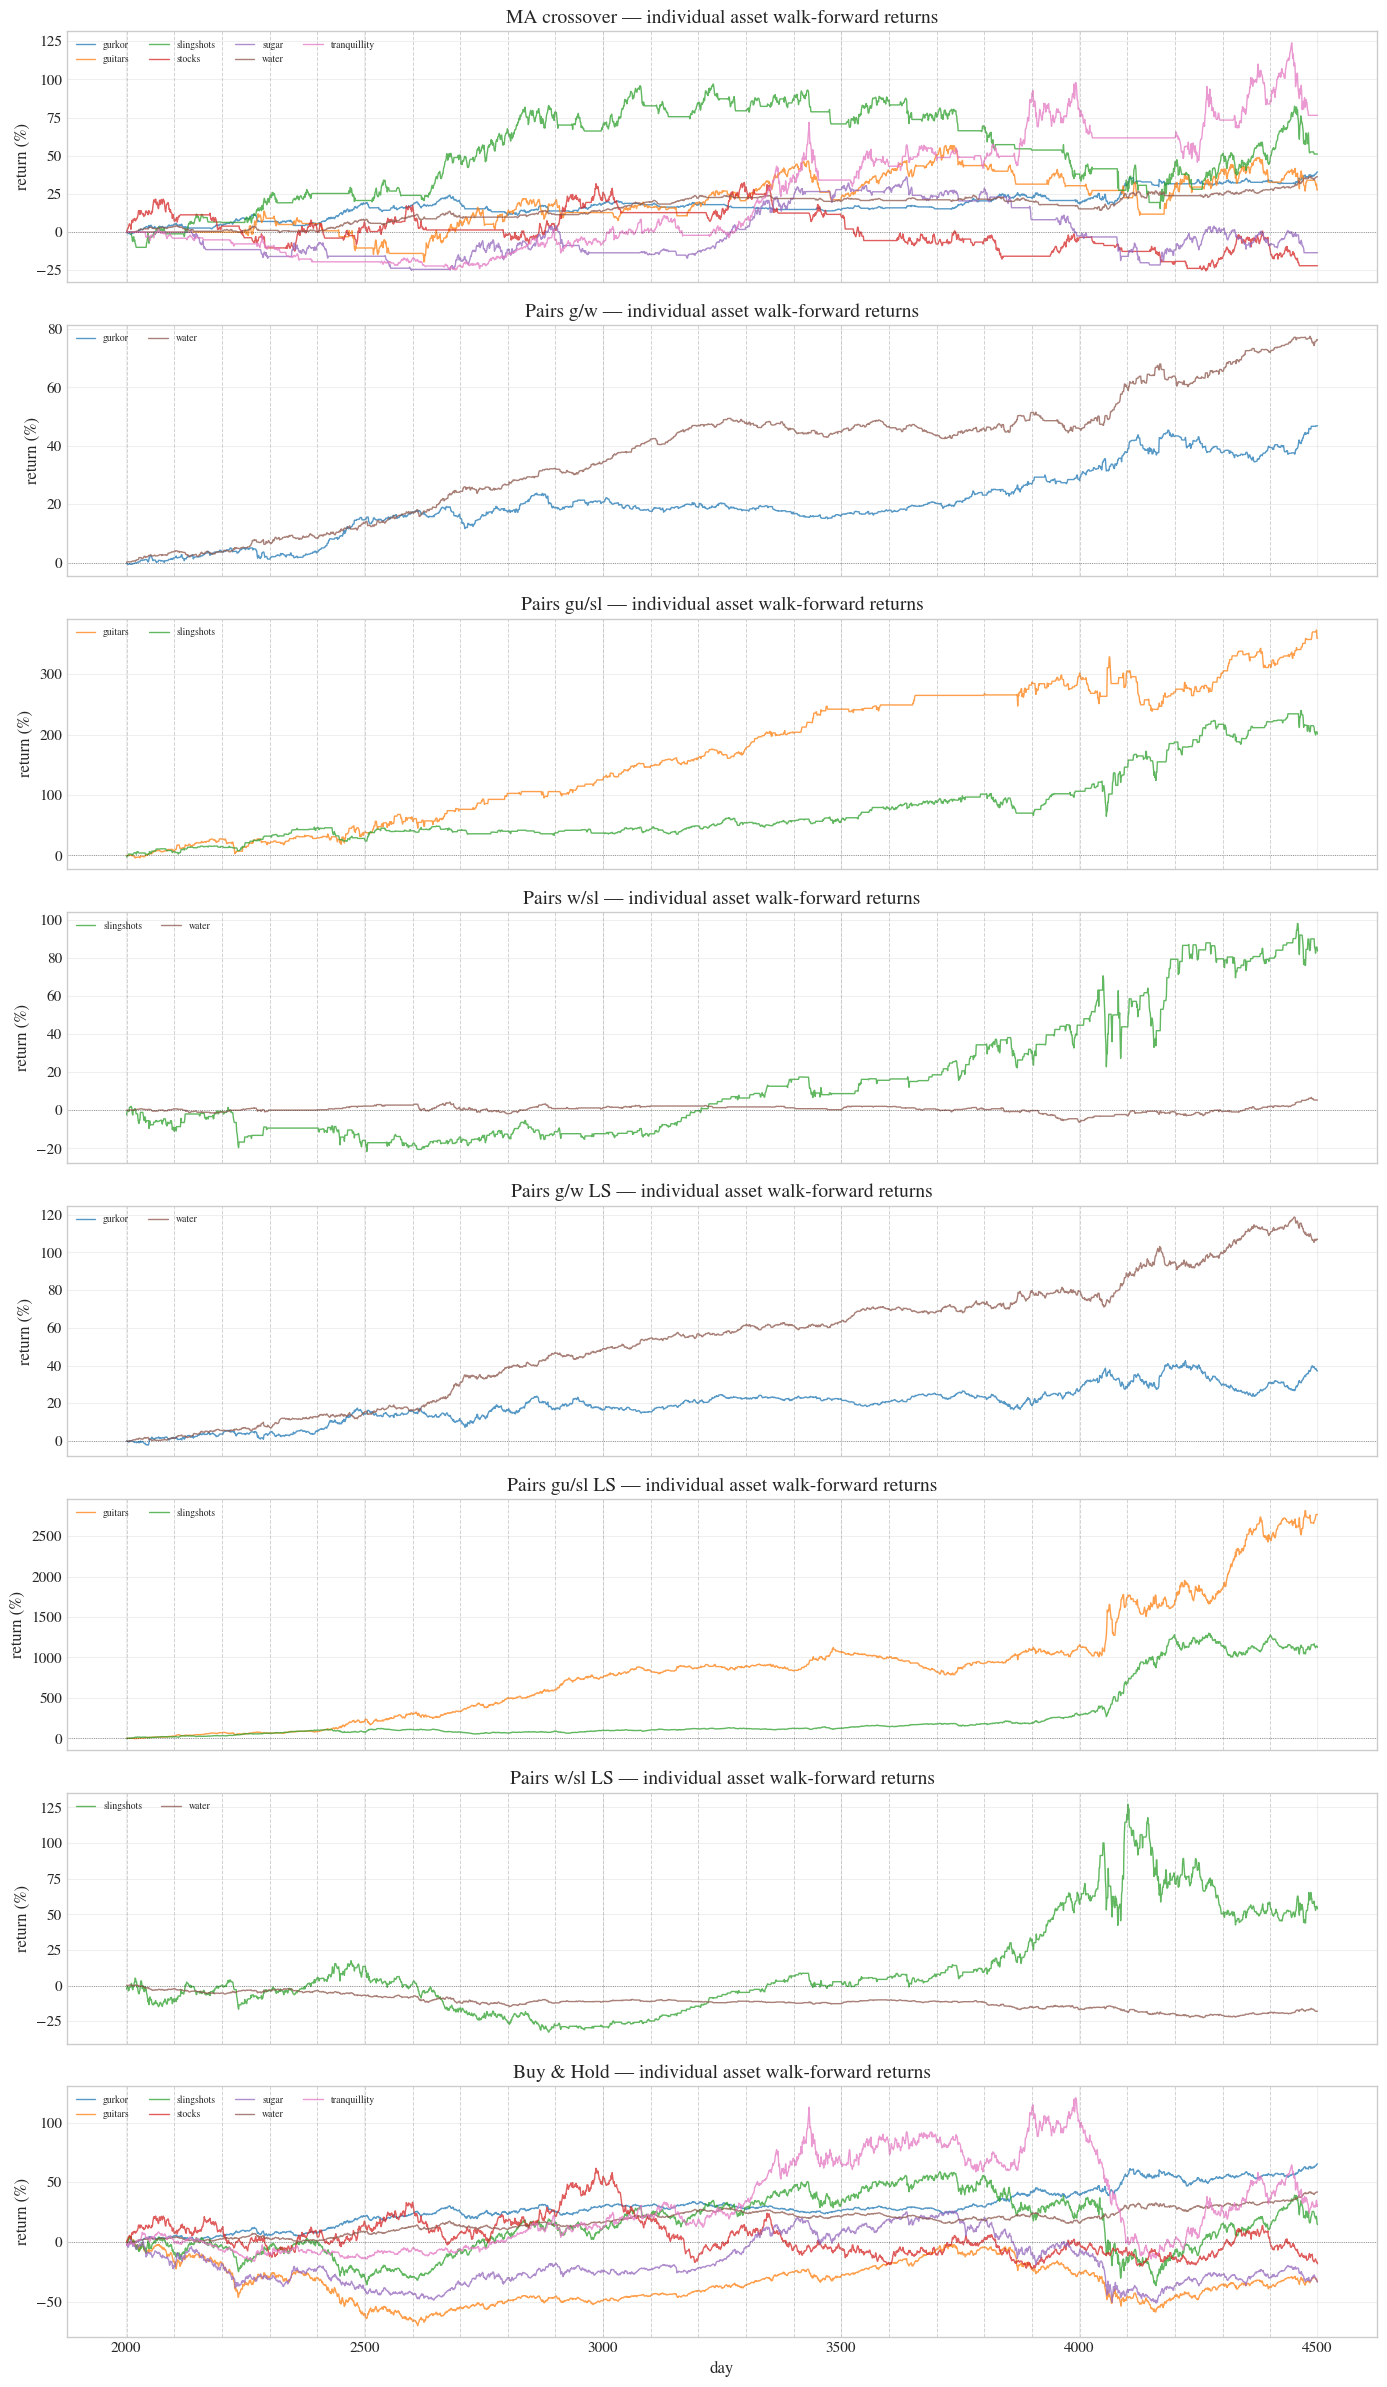

Stitched pseudo-OoS (walk-forward) — per (strategy, asset) metrics:


ann_return   cagr  excess_riskfree  excess_ret  \
Strategy       Asset                                                          
MA crossover   gurkor              4.84   4.96            0.020        -2.6   
               guitars             3.56   3.63            0.006         9.3   
               slingshots          6.03   6.21            0.032         4.2   
               stocks             -3.63  -3.56           -0.066        -0.6   
               sugar              -2.11  -2.09           -0.051         3.8   
               water               4.51   4.61            0.016        -0.6   
               tranquillity        8.29   8.64            0.056         4.6   
Pairs g/w      gurkor              5.61   5.77            0.028        -1.8   
               water               8.28   8.63            0.056         3.4   
Pairs gu/sl    guitars            22.26  24.94            0.219        30.6   
               slingshots         16.10  17.47            0.145        15.5   
Pairs w/sl     slingshots          8.86   9.27            0.063         7.3   
               water               0.76   0.76           -0.022        -4.5   
Pairs g/w LS   gurkor              4.61   4.72            0.017        -2.9   
               water              10.61  11.20            0.082         6.0   
Pairs gu/sl LS guitars            49.00  63.23            0.602        68.9   
               slingshots         36.60  44.20            0.412        42.2   
Pairs w/sl LS  slingshots          6.29   6.49            0.035         4.5   
               water              -2.88  -2.84           -0.058        -8.1   

                             ann_vol  sharpe  bh_sharpe  max_drawdown  \
Strategy       Asset                                                    
MA crossover   gurkor           6.76   0.273      0.524         -10.7   
               guitars         18.45   0.030     -0.281         -29.3   
               slingshots      20.87   0.145     -0.032         -41.4   
               stocks          20.76  -0.319     -0.211         -43.7   
               sugar           18.20  -0.281     -0.282         -42.4   
               water            5.05   0.299      0.338          -8.1   
               tranquillity    21.73   0.243      0.035         -26.4   
Pairs g/w      gurkor           5.67   0.460      0.524          -7.4   
               water            4.39   1.201      0.338          -4.7   
Pairs gu/sl    guitars         19.23   1.002     -0.281         -21.0   
               slingshots      19.79   0.662     -0.032         -26.1   
Pairs w/sl     slingshots      21.39   0.274     -0.032         -28.0   
               water            3.77  -0.594      0.338         -10.1   
Pairs g/w LS   gurkor           7.71   0.209      0.524         -13.2   
               water            5.76   1.321      0.338          -6.1   
Pairs gu/sl LS guitars         27.47   1.675     -0.281         -27.6   
               slingshots      27.43   1.225     -0.032         -31.6   
Pairs w/sl LS  slingshots      26.74   0.123     -0.032         -42.7   
               water            5.11  -1.150      0.338         -22.9   

                             trades_per_year  avg_hold_days  \
Strategy       Asset                                          
MA crossover   gurkor                   18.2           12.1   
               guitars                   9.9           20.1   
               slingshots               14.7           14.2   
               stocks                    5.0           39.6   
               sugar                    18.7            9.4   
               water                    11.8           18.9   
               tranquillity             12.7           17.6   
Pairs g/w      gurkor                   98.1            1.7   
               water                    97.1            1.8   
Pairs gu/sl    guitars                  54.6            2.3   
               slingshots               54.0            2.4   
Pairs w/sl     s

In [63]:
# ── per-strategy equity, one line per asset ───────────────────────────────────
n_strats = len(wf_specs)
fig, axes = plt.subplots(
    n_strats, 1,
    figsize=(14, 3 * n_strats),
    sharex=True,
)

if n_strats == 1:
    axes = [axes]

for ax_eq, (label, wf_ret, wf_sum) in zip(axes, wf_specs):
    for col in wf_ret.columns:
        ret = wf_ret[col]
        if (ret == 0).all():
            continue
        color = asset_colors.get(col, "gray")

        # equity curve in price space
        log_cum     = ret.cumsum()
        padded      = pd.concat([pd.Series([0.0], index=[log_cum.index[0] - 1]), log_cum])
        equity      = (np.exp(padded).iloc[1:] - 1) * 100
        ax_eq.plot(equity.index, equity.values, linewidth=1.0, alpha=0.75,
                   color=color, label=col)

    for _, row in wf_sum.iterrows():
        ax_eq.axvline(row["OoS start"], color="gray", linewidth=0.7, linestyle="--", alpha=0.35)

    ax_eq.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
    ax_eq.set_title(f"{label} — individual asset walk-forward returns")
    ax_eq.set_ylabel("return (%)")
    ax_eq.legend(fontsize=7, ncol=4, loc="upper left")
    ax_eq.grid(True, alpha=0.3)

axes[-1].set_xlabel("day")

plt.tight_layout()
plt.savefig(output / "walk_forward_returns.png", bbox_inches="tight")
plt.show()



# ── Stitched pseudo-OoS metrics — per (strategy, asset) ──────────────────────
METRIC_COLS = [
    "ann_return", "cagr","excess_riskfree","excess_ret", "ann_vol", "sharpe","bh_sharpe",
    "max_drawdown", "trades_per_year", "avg_hold_days",
    "positive_sharpe_folds", 
]

rows = []
for label, wf_ret, wf_sum in wf_specs:
    for asset in wf_ret.columns:
        ret = wf_ret[asset]
        if (ret == 0).all():
            continue

        # count folds where Sharpe > 0
        positive_sharpe_folds = 0
        for _, row in wf_sum.iterrows():
            fold_ret = wf_ret[asset].loc[row["OoS start"]:row["OoS end"]].dropna()
            if (fold_ret == 0).all():
                continue

            v = fold_ret.std() * np.sqrt(365)
            sr = (fold_ret.mean() * 365 - RF) / v if v > 0 else np.nan

            if pd.notna(sr) and sr > 0:
                positive_sharpe_folds += 1

        bh_asset = wf_ret_bh[asset] if asset in wf_ret_bh.columns else None
        m = backtest_metrics(ret, bh_ret=bh_asset)

        rows.append({
            "Strategy": label,
            "Asset": asset,
            "positive_sharpe_folds": positive_sharpe_folds/len(wf_sum),
            **{k: round(v, 3) if isinstance(v, float) else v for k, v in m.items()}
        })

wf_metrics_df = pd.DataFrame(rows).set_index(["Strategy", "Asset"])
wf_metrics_df['excess_sharpe'] = wf_metrics_df['sharpe'] - wf_metrics_df['bh_sharpe']
wf_metrics_df['excess_ret'] = wf_metrics_df['excess_ret']*100
wf_metrics_df['max_drawdown'] = wf_metrics_df['max_drawdown']*100




print("Stitched pseudo-OoS (walk-forward) — per (strategy, asset) metrics:")
display(wf_metrics_df[METRIC_COLS].drop('Buy & Hold', level=0))
wf_metrics_df[METRIC_COLS].drop('Buy & Hold', level=0).reset_index().to_latex(output / "walk_forward_metrics.tex", index=False, float_format="%.2f")

### 8.1.1 Parameter Stability Across Folds

One of the key overfitting warning signs listed in Section 6 is: *"parameters change dramatically fold-to-fold."* The walk-forward above shows **whether** the strategy works across folds; this section shows **which parameters were chosen** on each expanding IS window.

**Interpretation guide:**
| Pattern | Verdict |
|---------|---------|
| Same parameter value across all folds | Stable — the optimiser found a robust setting |
| Gradual drift as IS window grows | Mild instability — may reflect genuine regime shift |
| Random jumps across the full grid range | Red flag — fitting noise, not a market relationship |

For MA crossover, each cell shows the parameter chosen for that asset on that fold's IS window. High cross-asset agreement also indicates a genuine signal (all assets respond to the same parameter range).

In [30]:
def collect_fold_params(
    prices: pd.DataFrame,
    signal_fn,
    param_grid: list[dict],
    is_size: int = IS_SIZE,
    oos_size: int = OOS_SIZE,
    step: int = WF_STEP,
    per_asset: bool = False,
) -> pd.DataFrame:
    """
    Re-run IS grid search on each sliding fold window and record the chosen parameters.
    Mirrors the walk_forward window schedule: IS = [fold*step, fold*step+is_size).
    per_asset=True  -> rows keyed by (fold, asset)
    per_asset=False -> rows keyed by fold
    """
    n = len(prices)
    records = []
    fold = 0
    while True:
        is_start = fold * step
        is_end   = is_start + is_size
        if is_end + oos_size > n:
            break
        p_is = prices.iloc[is_start:is_end]
        if per_asset:
            best_p = per_asset_grid_search(p_is, signal_fn, param_grid)
            for asset, params in best_p.items():
                records.append({"fold": fold + 1, "asset": asset, **params})
        else:
            orig_types = {k: type(v) for k, v in param_grid[0].items()}
            g        = grid_search(p_is, signal_fn, param_grid)
            best_row = g.loc[g["sharpe"].idxmax()]
            best_p   = {k: orig_types[k](best_row[k]) for k in orig_types}
            records.append({"fold": fold + 1, **best_p})
        fold += 1
    return pd.DataFrame(records)


print("Collecting per-fold IS-optimal parameters (this reuses the grid search infrastructure)...")
fold_ma   = collect_fold_params(prices_is, ma_crossover_signal, MA_PARAM_GRID,   per_asset=True)
fold_gw   = collect_fold_params(prices_is, gw_signal,           PAIRS_PARAM_GRID, per_asset=False)
fold_gusl = collect_fold_params(prices_is, gusl_signal,         PAIRS_PARAM_GRID, per_asset=False)
print("Done.")

# Summary: coefficient of variation across folds to flag instability
print("Parameter range across folds (max - min) — larger = less stable:")
for name, df, params in [
    ("MA crossover", fold_ma,  ["fast", "slow"]),
]:
    ranges = df.groupby("asset")[params].agg(lambda x: x.max() - x.min())
    print(f"{name}") 
    display(ranges)

Done.
Parameter range across folds (max - min) — larger = less stable:
MA crossover


,fast,slow
asset,,
guitars,20,180
gurkor,20,232
slingshots,20,232
stocks,20,232
sugar,20,232
tranquillity,20,232
water,20,130


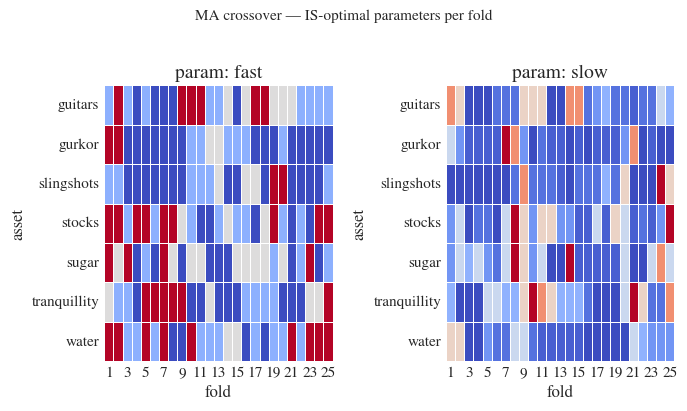


Pairs g/w — fold parameters:


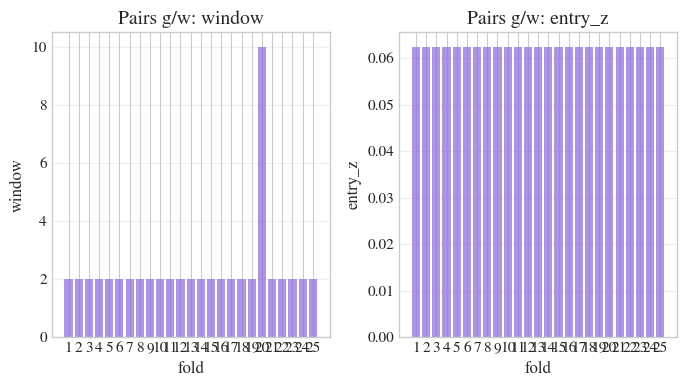


Pairs gu/sl — fold parameters:


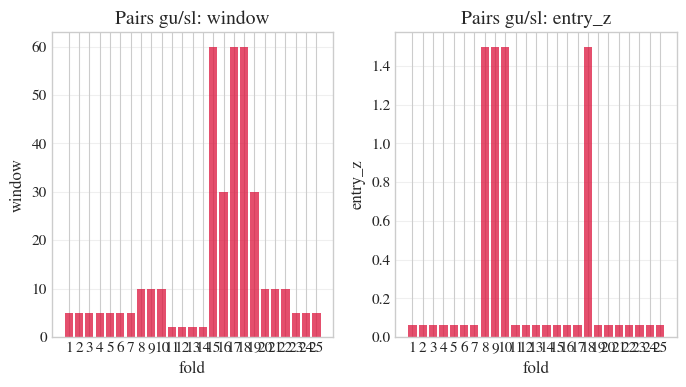

In [48]:
def plot_param_stability(fold_df, params, strategy_name, figsize=None):
    """
    One heatmap per parameter: rows = assets (or single row for portfolio-level),
    columns = folds. Color encodes the chosen parameter value.
    """
    has_asset = "asset" in fold_df.columns
    n_params  = len(params)
    fig, axes = plt.subplots(1, n_params)
    if n_params == 1:
        axes = [axes]

    for ax, param in zip(axes, params):
        if has_asset:
            pivot = fold_df.pivot(index="asset", columns="fold", values=param)
        else:
            pivot = fold_df[["fold", param]].set_index("fold")[[param]].T
            pivot.index = [strategy_name]

        is_int = pd.api.types.is_integer_dtype(fold_df[param])
        fmt    = ".0f" if is_int else ".2g"

        vmin = fold_df[param].min()
        vmax = fold_df[param].max()

        sns.heatmap(
            pivot, annot=False, cmap="coolwarm", center=np.mean([vmin, vmax]),
            vmin=vmin, vmax=vmax, linewidths=0.5, cbar=False, ax=ax,
        )
        ax.set_title(f"param: {param}")
        ax.set_xlabel("fold")
        ax.set_ylabel("asset" if has_asset else "")
        ax.tick_params(axis="x", labelrotation=0)

    fig.suptitle(f"{strategy_name} — IS-optimal parameters per fold", fontsize=11, y=1.02)
    plt.tight_layout()
    return fig


# MA crossover
fig = plot_param_stability(fold_ma, ["fast", "slow"], "MA crossover")
plt.show()

# Pairs: portfolio-level — just a table with a bar chart overlay
for name, df in [("Pairs g/w", fold_gw), ("Pairs gu/sl", fold_gusl)]:
    print(f"\n{name} — fold parameters:")
    # display(df.set_index("fold"))
    fig, axes = plt.subplots(1, 2)
    for ax, param in zip(axes, ["window", "entry_z"]):
        ax.bar(df["fold"], df[param], color="mediumpurple" if name == "Pairs g/w" else "crimson", alpha=0.75)
        ax.set_title(f"{name}: {param}")
        ax.set_xlabel("fold"); ax.set_ylabel(param)
        ax.set_xticks(df["fold"])
        ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    fname = "param_stability_gw.png" if name == "Pairs g/w" else "param_stability_gusl.png"
    plt.show()

### 8.2 Bootstrap Sharpe Significance

#### Why bootstrap instead of a t-test?

The most natural question about a strategy is: *could the observed positive Sharpe ratio have arisen purely by chance?*

A classical t-test answers this by assuming daily returns are i.i.d. normal — an assumption financial returns routinely violate (heavy tails, skewness, volatility clustering). The **bootstrap** is distribution-free: it estimates the sampling distribution of the Sharpe ratio directly from the observed returns, with no parametric assumptions imposed.

#### The procedure

For each active (asset, strategy) pair with walk-forward stitched returns $r_1, \ldots, r_T$:

1. **Resample:** draw $T$ observations **with replacement** from $\{r_1, \ldots, r_T\}$ to form a bootstrap sample $r^*_1, \ldots, r^*_T$.
2. **Compute** the annualised Sharpe of the bootstrap sample: $\widehat{SR}^* = \sqrt{365}\; \bar{r}^* / s^*$.
3. **Repeat** steps 1–2 $B = 2000$ times, producing a bootstrap distribution $\{\widehat{SR}^*_b\}_{b=1}^{B}$.
4. **p-value:** $\displaystyle p = \frac{1}{B}\sum_{b=1}^{B}\mathbf{1}[\widehat{SR}^*_b \leq 0]$ — the fraction of bootstrap worlds in which the Sharpe is non-positive.

A small $p$ means the observed positive Sharpe is hard to attribute to sampling noise. We also read off the 5th–95th percentile interval as a 90 % confidence band.

#### Important limitation: iid assumption

Resampling with replacement **destroys temporal order**, which breaks any serial dependence in returns. A trend-following strategy that holds a position for weeks produces runs of correlated positive or negative returns; the bootstrap treats each day as an independent draw, so it underestimates the true variance of the Sharpe estimator. In practice this makes the reported p-value **optimistically small** — the true uncertainty is higher.

Using walk-forward stitched returns (rather than IS bootstrap) partially mitigates this: the strategy was re-tuned across multiple non-overlapping sub-folds, so there is less look-ahead contamination than a single IS evaluation would have. But the iid limitation remains and results should be interpreted with that caveat in mind.

#### The multiple testing problem

We run one hypothesis test per active (asset, strategy) pair. With 7 assets and 6 strategies, there are up to **42 simultaneous tests**. Even if no strategy has any real edge, we expect

$$42 \times 0.05 = 2.1 \text{ false discoveries at } \alpha = 0.05$$

purely by chance. The more tests run without correction, the more likely at least one appears spuriously "significant". This is the **multiple comparisons problem**, and ignoring it is one of the most common sources of false positives in quantitative research.

#### Why Benjamini-Hochberg rather than Bonferroni

| Correction | Controls | Adjusted threshold |
|------------|---------|-------------------|
| None | Nothing | $\alpha = 0.05$ per test |
| Bonferroni | Family-wise error rate (FWER) | $\alpha / m \approx 0.05 / 42 \approx 0.0012$ |
| **BH (used here)** | **False discovery rate (FDR)** | **Adaptive — see below** |

**Bonferroni** controls the probability that *any* null is falsely rejected across the entire family of tests. Because our 42 tests all share the same underlying price data, they are strongly correlated — Bonferroni overcorrects and is far too conservative, discarding real signals alongside noise.

**Benjamini-Hochberg (BH)** controls the **false discovery rate**: the *expected proportion* of rejected nulls that are false positives. At FDR $= 10\%$, of all (asset, strategy) pairs we flag as significant, at most $10\%$ are expected to be spurious. The BH procedure:

1. Sort the $m$ raw p-values: $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$.
2. Find the largest $k$ such that $\displaystyle p_{(k)} \leq \frac{k}{m}\,\alpha_{\text{FDR}}$.
3. Reject hypotheses $1, \ldots, k$.

BH is proven valid under **any positive dependence structure** — a weaker and more realistic assumption for financial data where assets share common market factors. The adjusted p-value for hypothesis $i$ is $\min\bigl(p_{(i)} \cdot m / i,\; 1\bigr)$, taken as a running minimum from right to left to enforce monotonicity.

#### Reading the three heatmaps

| Heatmap | What it shows | How to read it |
|---------|--------------|---------------|
| **Sharpe** | Point estimate of annualised Sharpe | Positive = earns a risk premium on average |
| **Raw p-value** | $P(SR \leq 0)$ before correction | Directional evidence; $< 0.05$ is nominally significant |
| **BH-adjusted p-value** | After correcting for ~42 simultaneous tests | The honest bar — $< 0.10$ survives multiple testing at FDR 10 % |

The strongest evidence the notebook can offer is a cell that is (i) positive in the Sharpe heatmap, (ii) green in the BH-adjusted heatmap, and (iii) consistent across most folds in the dot plot (§8.1). A strategy that clears only the raw threshold but not the BH threshold should be treated with scepticism — it may simply be one of the lucky false discoveries expected from running 42 tests.

Raw bootstrap p-values P(SR ≤ 0):


,MA crossover,Pairs g/w,Pairs gu/sl,Pairs g/w LS,Pairs gu/sl LS,Buy & Hold
gurkor,0.246,0.108,NaN,0.293,NaN,0.091
guitars,0.478,NaN,0.004,NaN,0.000,0.788
slingshots,0.356,NaN,0.042,NaN,0.001,0.537
stocks,0.789,NaN,NaN,NaN,NaN,0.700
sugar,0.766,NaN,NaN,NaN,NaN,0.780
water,0.216,0.001,NaN,0.000,NaN,0.195
tranquillity,0.265,NaN,NaN,NaN,NaN,0.474



BH-adjusted p-values (FDR control):


,MA crossover,Pairs g/w,Pairs gu/sl,Pairs g/w LS,Pairs gu/sl LS,Buy & Hold
gurkor,0.486,0.297,NaN,0.496,NaN,0.286
guitars,0.657,NaN,0.018,NaN,0.000,0.789
slingshots,0.559,NaN,0.154,NaN,0.005,0.695
stocks,0.789,NaN,NaN,NaN,NaN,0.789
sugar,0.789,NaN,NaN,NaN,NaN,0.789
water,0.475,0.005,NaN,0.000,NaN,0.475
tranquillity,0.486,NaN,NaN,NaN,NaN,0.657


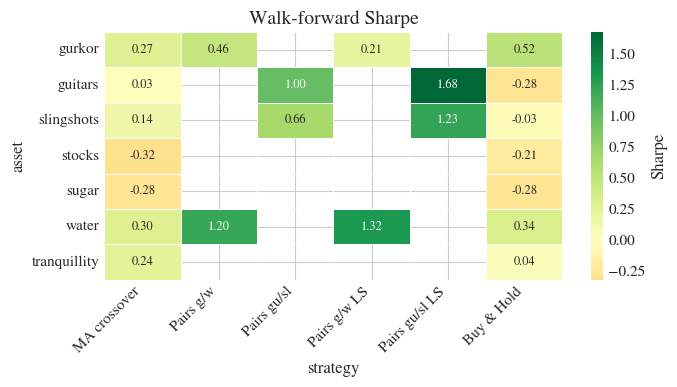

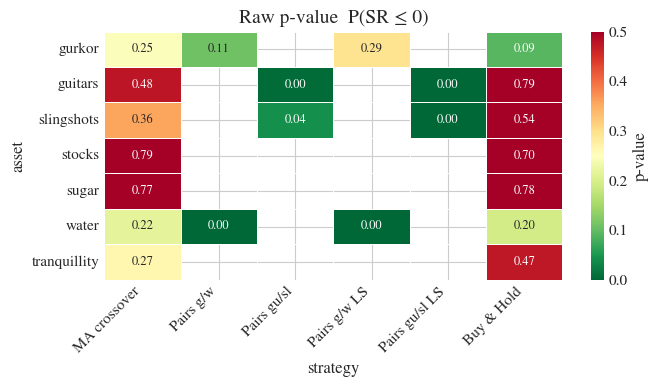

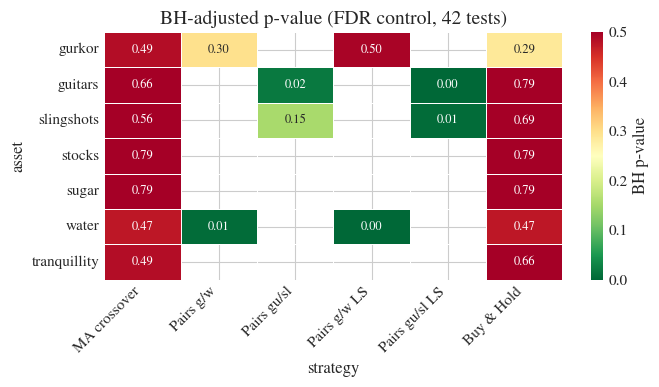

In [39]:
N_BOOT = 2000

def bootstrap_sr_pvalue(ret_series, n_boot=N_BOOT, ann=365, random_state=42):
    """Bootstrap p-value: fraction of resampled Sharpes <= 0."""
    rng  = np.random.default_rng(random_state)
    vals = ret_series.dropna().values
    if len(vals) < 10 or (vals == 0).all():
        return np.nan, np.nan, np.nan
    n    = len(vals)
    boot_srs = []
    for _ in range(n_boot):
        s   = rng.choice(vals, size=n, replace=True)
        vol = s.std() * np.sqrt(ann)
        boot_srs.append((s.mean() * ann - RF) / vol if vol > 0 else np.nan)
    boot_srs = np.array(boot_srs)
    actual_sr = (vals.mean() * ann - RF) / (vals.std() * np.sqrt(ann))
    lo, hi    = np.nanpercentile(boot_srs, [5, 95])
    p_val     = float(np.nanmean(boot_srs <= 0))
    return round(actual_sr, 3), round(p_val, 3), (round(lo, 3), round(hi, 3))

# compute per (asset, strategy)
sr_mat = pd.DataFrame(index=prices_is.columns, columns=[l for l,_,_ in wf_specs])
pv_mat = pd.DataFrame(index=prices_is.columns, columns=[l for l,_,_ in wf_specs])

for label, wf_ret, _ in wf_specs:
    for col in prices_is.columns:
        sr, pv, _ = bootstrap_sr_pvalue(wf_ret[col])
        sr_mat.loc[col, label] = sr
        pv_mat.loc[col, label] = pv

sr_mat = sr_mat.astype(float)
pv_mat = pv_mat.astype(float)


def make_annot(df, exp_flag):
    annot = df.copy().astype(object)
    for col in df.columns:
        for idx in df.index:
            v = df.loc[idx, col]
            annot.loc[idx, col] = "flat" if exp_flag.loc[idx, col] else (f"{v:.2f}" if not pd.isna(v) else "n/a")
    return annot

# ── Benjamini-Hochberg FDR correction ────────────────────────────────────────
# Only adjust active (asset, strategy) pairs — flat pairs are excluded.
ever_active = pd.DataFrame({
    label: {col: (wf_ret[col] != 0).any() for col in prices_is.columns}
    for label, wf_ret, _ in wf_specs
})

def bh_adjust(pv_matrix, active_mask):
    """
    Benjamini-Hochberg adjustment across all active tests.
    Returns a DataFrame of BH-adjusted p-values (NaN where inactive).
    """
    flat_idx  = [(r, c) for r in pv_matrix.index for c in pv_matrix.columns
                 if active_mask.loc[r, c] and not pd.isna(pv_matrix.loc[r, c])]
    if not flat_idx:
        return pv_matrix.copy()
    raw = np.array([pv_matrix.loc[r, c] for r, c in flat_idx])
    m   = len(raw)
    order = np.argsort(raw)
    rank  = np.empty(m, dtype=int)
    rank[order] = np.arange(1, m + 1)
    # BH adjusted: p_adj_i = p_i * m / rank_i, then take running min from right
    adj = raw * m / rank
    # enforce monotonicity (take cumulative min from the largest rank downward)
    for i in order[::-1]:
        right_neighbors = [adj[j] for j in range(m) if rank[j] > rank[i]]
        if right_neighbors:
            adj[i] = min(adj[i], min(right_neighbors))
    adj = np.minimum(adj, 1.0)
    pv_bh = pv_matrix.copy().astype(float) * np.nan
    for (r, c), v in zip(flat_idx, adj):
        pv_bh.loc[r, c] = round(float(v), 3)
    return pv_bh

pv_bh = bh_adjust(pv_mat, ever_active)

print("Raw bootstrap p-values P(SR ≤ 0):")
display(pv_mat.round(5))
print("\nBH-adjusted p-values (FDR control):")
display(pv_bh.round(5))

annot_sr = make_annot(sr_mat, ~ever_active)

plt.figure()
ax = sns.heatmap(
    sr_mat,
    annot=annot_sr,
    fmt="",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Sharpe"},
    annot_kws={"size": 9},
)

ax.set_title("Walk-forward Sharpe")
ax.set_ylabel("asset")
ax.set_xlabel("strategy")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")

plt.tight_layout()
plt.savefig(output / "bootstrap_sharpe_sr.png", bbox_inches="tight")
plt.show()

pv_plot = pv_mat.where(ever_active)
annot_pv = make_annot(pv_mat, ~ever_active)

plt.figure()
ax = sns.heatmap(
    pv_plot,
    annot=annot_pv,
    fmt="",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=0.5,
    linewidths=0.5,
    cbar_kws={"label": "p-value"},
    annot_kws={"size": 9},
)

ax.set_title("Raw p-value  P(SR ≤ 0)")
ax.set_ylabel("asset")
ax.set_xlabel("strategy")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")

plt.tight_layout()
plt.savefig(output / "bootstrap_sharpe_pv_raw.png", bbox_inches="tight")
plt.show()

bh_plot = pv_bh.where(ever_active)
annot_bh = make_annot(pv_bh, ~ever_active)

plt.figure()
ax = sns.heatmap(
    bh_plot,
    annot=annot_bh,
    fmt="",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=0.5,
    linewidths=0.5,
    cbar_kws={"label": "BH p-value"},
    annot_kws={"size": 9},
)

ax.set_title("BH-adjusted p-value (FDR control, 42 tests)")
ax.set_ylabel("asset")
ax.set_xlabel("strategy")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")

plt.tight_layout()
plt.savefig(output / "bootstrap_sharpe_pv_bh.png", bbox_inches="tight")
plt.show()

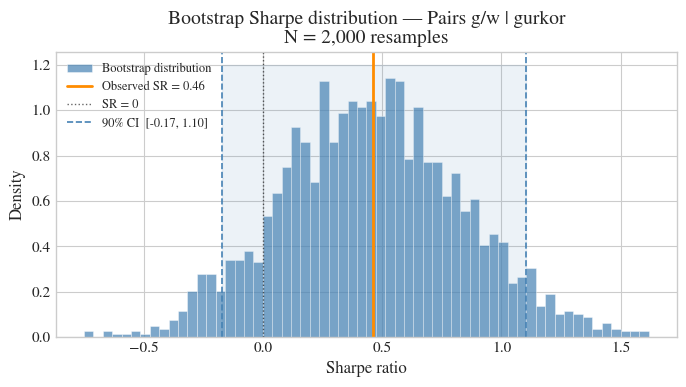

In [ ]:
# ── Bootstrap Sharpe distribution: Pairs g/w | gurkor ────────────────────────
_STRATEGY = "Pairs g/w"
_ASSET    = "gurkor"

_wf_ret = next(wf_ret for label, wf_ret, _ in wf_specs if label == _STRATEGY)
_vals   = _wf_ret[_ASSET].dropna().values

# Re-run bootstrap keeping the full distribution
_rng      = np.random.default_rng(42)
_n        = len(_vals)
_boot_srs = []
for _ in range(N_BOOT):
    _s   = _rng.choice(_vals, size=_n, replace=True)
    _vol = _s.std() * np.sqrt(365)
    _boot_srs.append((_s.mean() * 365 - RF) / _vol if _vol > 0 else np.nan)
_boot_srs  = np.array(_boot_srs)
_actual_sr = (_vals.mean() * 365 - RF) / (_vals.std() * np.sqrt(365))
_lo, _hi   = np.nanpercentile(_boot_srs, [5, 95])
_p_val     = float(np.nanmean(_boot_srs <= 0))

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(_boot_srs[~np.isnan(_boot_srs)], bins=60, color="steelblue",
        alpha=0.7, edgecolor="white", linewidth=0.4, density=True,
        label="Bootstrap distribution")

ax.axvline(_actual_sr, color="darkorange", linewidth=2.0, linestyle="-",
           label=f"Observed SR = {_actual_sr:.2f}")
ax.axvline(0, color="black", linewidth=1.0, linestyle=":", alpha=0.6,
           label="SR = 0")
ax.axvline(_lo, color="steelblue", linewidth=1.2, linestyle="--",
           label=f"90% CI  [{_lo:.2f}, {_hi:.2f}]")
ax.axvline(_hi, color="steelblue", linewidth=1.2, linestyle="--")

ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                 _lo, _hi, alpha=0.10, color="steelblue")

ax.set_xlabel("Sharpe ratio")
ax.set_ylabel("Density")
ax.set_title(f"Bootstrap Sharpe distribution — {_STRATEGY} | {_ASSET}\n"
              f"N = {N_BOOT:,} resamples")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(output / "bootstrap_sr_pairs_gw_gurkor.png", bbox_inches="tight")
plt.show()


### 8.3 Per-Asset Breakdown

Each **(asset, strategy)** pair is evaluated independently. The heatmap shows the walk-forward pseudo-OoS Sharpe for every pair — pairs strategies show "flat" for the 5 assets they never trade. This is the primary performance summary: consistent positive Sharpe across most assets indicates a genuine signal; isolated bright cells suggest the strategy works by luck on one asset.

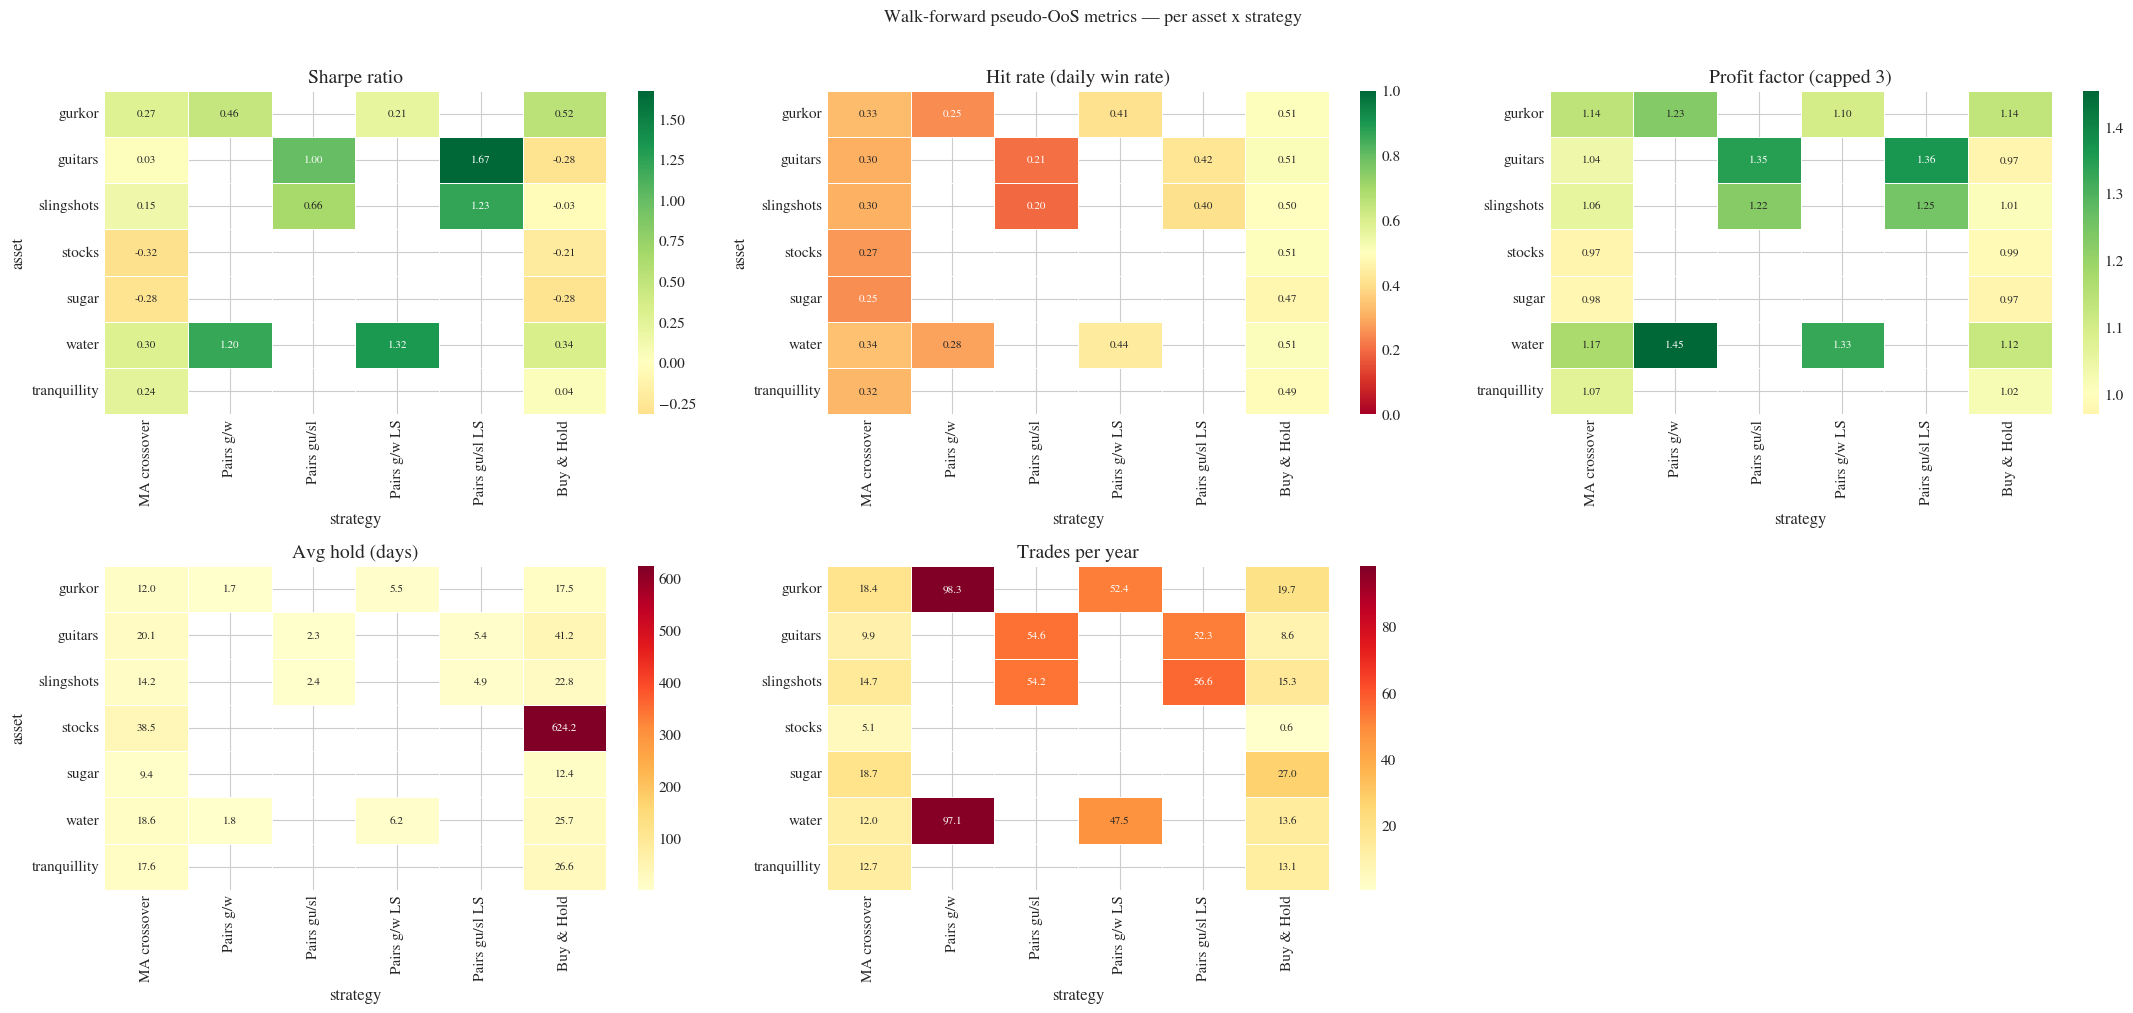

Walk-forward Sharpe:
              MA crossover  Pairs g/w  Pairs gu/sl  Pairs g/w LS  \
gurkor               0.273      0.460          NaN         0.209   
guitars              0.030        NaN        1.002           NaN   
slingshots           0.145        NaN        0.662           NaN   
stocks              -0.319        NaN          NaN           NaN   
sugar               -0.281        NaN          NaN           NaN   
water                0.299      1.201          NaN         1.321   
tranquillity         0.243        NaN          NaN           NaN   

              Pairs gu/sl LS  Buy & Hold  
gurkor                   NaN       0.524  
guitars                1.675      -0.281  
slingshots             1.225      -0.032  
stocks                   NaN      -0.211  
sugar                    NaN      -0.282  
water                    NaN       0.338  
tranquillity             NaN       0.035  

Walk-forward Hit rate:
              MA crossover  Pairs g/w  Pairs gu/sl  Pairs g/w LS  

In [33]:
def _wf_asset_sharpe(ret_series, ann=365):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    v = sr.std() * np.sqrt(ann)
    return (sr.mean() * ann - RF) / v if v > 0 else np.nan

def _wf_asset_hit_rate(ret_series):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    return float((sr > 0).mean())

def _wf_asset_profit_factor(ret_series):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    wins   = sr[sr > 0].sum()
    losses = sr[sr < 0].sum()
    return float(wins / abs(losses)) if losses != 0 else np.nan

def _wf_asset_avg_hold(ret_series):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    active   = (sr != 0).astype(int)
    n_trades = int(((active == 1) & (active.shift(1, fill_value=0) == 0)).sum())
    return float(active.sum() / n_trades) if n_trades > 0 else np.nan

def _wf_asset_trades_per_year(ret_series, ann=365):
    sr = ret_series.dropna()
    if sr.empty or (sr == 0).all():
        return np.nan
    active   = (sr != 0).astype(int)
    n_trades = int(((active == 1) & (active.shift(1, fill_value=0) == 0)).sum())
    return float(n_trades / (len(sr) / ann)) if len(sr) > 0 else np.nan

sharpe_wf  = {}
hitrate_wf = {}
pf_wf      = {}
hold_wf    = {}
tpy_wf     = {}
exposure_wf = {}
for label, wf_ret, _ in wf_specs:
    sharpe_wf[label]   = {col: _wf_asset_sharpe(wf_ret[col])         for col in prices_is.columns}
    hitrate_wf[label]  = {col: _wf_asset_hit_rate(wf_ret[col])       for col in prices_is.columns}
    pf_wf[label]       = {col: _wf_asset_profit_factor(wf_ret[col])  for col in prices_is.columns}
    hold_wf[label]     = {col: _wf_asset_avg_hold(wf_ret[col])       for col in prices_is.columns}
    tpy_wf[label]      = {col: _wf_asset_trades_per_year(wf_ret[col]) for col in prices_is.columns}
    exposure_wf[label] = {col: float((wf_ret[col] != 0).mean())       for col in prices_is.columns}

per_asset_wf    = pd.DataFrame(sharpe_wf)
per_hitrate_wf  = pd.DataFrame(hitrate_wf)
per_pf_wf       = pd.DataFrame(pf_wf)
per_hold_wf     = pd.DataFrame(hold_wf)
per_tpy_wf      = pd.DataFrame(tpy_wf)
per_exposure_wf = pd.DataFrame(exposure_wf)

def _annot_wf(value_df, exp_df, fmt="{:.2f}"):
    annot = value_df.copy().astype(object)
    for col in annot.columns:
        for idx in annot.index:
            exp = exp_df.loc[idx, col]
            v   = value_df.loc[idx, col]
            annot.loc[idx, col] = "flat" if exp == 0 else ("n/a" if pd.isna(v) else fmt.format(v))
    return annot

fig, axes = plt.subplots(2, 3, figsize=(22, 10))

panels = [
    (axes[0, 0], per_asset_wf,   "Sharpe ratio",                      "RdYlGn", 0,   None, None, "{:.2f}"),
    (axes[0, 1], per_hitrate_wf, "Hit rate (daily win rate)",          "RdYlGn", 0.5, 0,   1,    "{:.2f}"),
    (axes[0, 2], per_pf_wf.clip(upper=3),
                 per_pf_wf,      "Profit factor (capped 3)",           "RdYlGn", 1,   0,   None, "{:.2f}"),
    (axes[1, 0], per_hold_wf,    "Avg hold (days)",                    "YlOrRd", None,None, None, "{:.1f}"),
    (axes[1, 1], per_tpy_wf,     "Trades per year",                    "YlOrRd", None,None, None, "{:.1f}"),
]

# unpack profit factor separately (uses raw df for annotations but clipped for colour)
for entry in panels[:2]:
    ax, df, title, cmap, center, vmin, vmax, fmt = entry
    annot = _annot_wf(df, per_exposure_wf, fmt)
    kw = dict(annot=annot, fmt="", cmap=cmap, center=center, linewidths=0.5,
              ax=ax, annot_kws={"size": 8})
    if vmin is not None: kw["vmin"] = vmin
    if vmax is not None: kw["vmax"] = vmax
    sns.heatmap(df, **kw)
    ax.set_title(title); ax.set_ylabel("asset"); ax.set_xlabel("strategy")

# profit factor: colour on clipped df, annotations from raw
ax, df_clipped, df_raw, title, cmap, center, vmin, vmax, fmt = (*panels[2][:2], per_pf_wf, *panels[2][3:])
annot = _annot_wf(df_raw, per_exposure_wf, fmt)
sns.heatmap(df_clipped, annot=annot, fmt="", cmap=cmap, center=center,
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title(title); ax.set_ylabel(""); ax.set_xlabel("strategy")

for entry in panels[3:]:
    ax, df, title, cmap, center, vmin, vmax, fmt = entry
    annot = _annot_wf(df, per_exposure_wf, fmt)
    kw = dict(annot=annot, fmt="", cmap=cmap, linewidths=0.5,
              ax=ax, annot_kws={"size": 8})
    if center is not None: kw["center"] = center
    sns.heatmap(df, **kw)
    ax.set_title(title); ax.set_ylabel("asset" if ax in axes[:, 0] else ""); ax.set_xlabel("strategy")

axes[1, 2].set_visible(False)

plt.suptitle("Walk-forward pseudo-OoS metrics — per asset x strategy", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(output / "per_asset_metrics.png", bbox_inches="tight")
plt.show()

print("Walk-forward Sharpe:");       print(per_asset_wf.round(3))
print("\nWalk-forward Hit rate:");   print(per_hitrate_wf.round(3))
print("\nWalk-forward Profit factor:"); print(per_pf_wf.round(3))
print("\nWalk-forward Avg hold (days):"); print(per_hold_wf.round(1))
print("\nWalk-forward Trades/year:"); print(per_tpy_wf.round(1))


## 9. Summary

| Validation method | Question answered |
|-------------------|------------------|
| **Walk-forward** | Does IS parameter selection work consistently across multiple sub-windows? |
| **Parameter stability** | Are optimal parameters stable or noise-driven? |
| **Bootstrap CI** | Is the walk-forward Sharpe statistically distinguishable from zero? |
| **Per-asset breakdown** | Does performance hold across all assets or just a lucky few? |
| **Walk-forward MVP** | Does minimum-variance allocation hold up across IS sub-folds? |

**Bottom-line:** all evidence is based on walk-forward pseudo-OoS within the IS window. A strategy that genuinely clears the bar would need:
- Positive walk-forward Sharpe with 90% CI entirely above zero
- Consistent positive Sharpe across most folds and most assets
- Stable parameters fold-to-fold
- Walk-forward MVP Sharpe competitive with naive equal-weight

## 10. Portfolio Allocation — Efficient Frontier (Buy-and-Hold)

So far every strategy has treated all 7 assets with equal weight. A natural question is: **what passive weight vector over the assets is actually efficient?** Using IS log-returns we estimate each asset's expected return and covariance, then map the full risk-return opportunity set.

### Mean-Variance framework

For a long-only portfolio $\mathbf{w} \geq 0$, $\mathbf{1}^\top \mathbf{w} = 1$ over the $n$ assets:

$$\mu_p = \mathbf{w}^\top \boldsymbol{\mu}, \qquad \sigma_p = \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}\, \mathbf{w}}$$

The **efficient frontier** traces the minimum-variance portfolio at every achievable return level. Two special points:

| Portfolio | Definition |
|-----------|-----------|
| **MVP** | Minimum variance — no return constraint, leftmost frontier point |
| **Max-Sharpe** | Highest $\mu_p / \sigma_p$ — tangency point at $r_f = 0$ |
| **Equal-weight** | $w_i = 1/7$ — the implicit allocation used throughout the notebook |

**Estimation discipline:** $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$ estimated on IS data only.

IS annualised return per asset:
gurkor          0.0584
guitars        -0.0149
slingshots      0.0271
stocks          0.0015
sugar          -0.0419
water           0.0381
tranquillity    0.0512
dtype: float64

IS annualised volatility per asset:
[0.0803 0.3096 0.3175 0.2852 0.3107 0.0634 0.2582]

IS correlation matrix:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
gurkor,1.000,-0.303,-0.266,-0.053,-0.081,0.621,-0.135
guitars,-0.303,1.000,0.527,0.037,0.216,-0.317,0.243
slingshots,-0.266,0.527,1.000,0.026,0.124,-0.205,0.182
stocks,-0.053,0.037,0.026,1.000,-0.025,-0.056,0.010
sugar,-0.081,0.216,0.124,-0.025,1.000,-0.091,0.151
water,0.621,-0.317,-0.205,-0.056,-0.091,1.000,-0.149
tranquillity,-0.135,0.243,0.182,0.010,0.151,-0.149,1.000



MVP weights:
gurkor          0.209
guitars         0.053
slingshots      0.027
stocks          0.038
sugar           0.022
water           0.608
tranquillity    0.043
dtype: float64
  vol=0.0499  ret=0.0366  SR=0.132

Max-Sharpe weights:
gurkor          0.874
guitars         0.000
slingshots      0.041
stocks          0.000
sugar           0.000
water           0.000
tranquillity    0.085
dtype: float64
  vol=0.0692  ret=0.0565  SR=0.383

Equal-weight:
  vol=0.1158  ret=0.0171  SR=-0.112


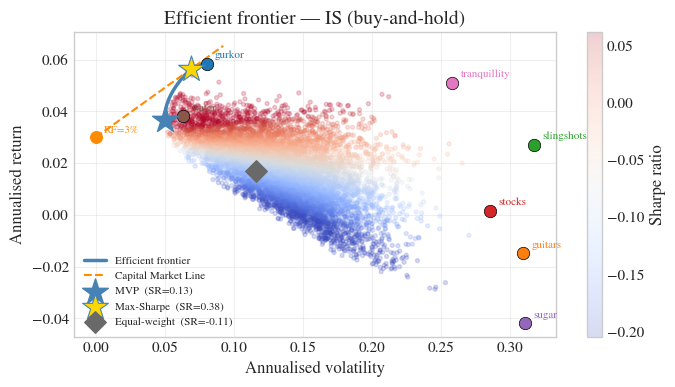

In [75]:
from scipy.optimize import minimize

# ── IS asset log-returns ──────────────────────────────────────────────────────
log_ret_is = np.log(prices_is).diff().dropna()

mu_a    = log_ret_is.mean() * 365
Sigma_a = log_ret_is.cov()  * 365
assets  = list(mu_a.index)
n_a     = len(assets)

print("IS annualised return per asset:")
print(mu_a.round(4))
print("\nIS annualised volatility per asset:")
print(np.sqrt(np.diag(Sigma_a.values)).round(4))
print("\nIS correlation matrix:")
display(log_ret_is.corr().round(3))

# ── optimisation helpers ──────────────────────────────────────────────────────
def port_vol(w): return float(np.sqrt(w @ Sigma_a.values @ w))
def port_ret(w): return float(w @ mu_a.values)
def neg_sharpe(w): v = port_vol(w); return -(port_ret(w) - RF) / v if v > 1e-10 else 0.0

bounds   = [(0.0, 1.0)] * n_a
sum_to_1 = {"type": "eq", "fun": lambda w: w.sum() - 1}
w0       = np.ones(n_a) / n_a

mvp = minimize(port_vol,   w0, method="SLSQP", bounds=bounds, constraints=[sum_to_1])
msr = minimize(neg_sharpe, w0, method="SLSQP", bounds=bounds, constraints=[sum_to_1])
mvp_w, msr_w = mvp.x, msr.x
ew_w = np.ones(n_a) / n_a

print("\nMVP weights:");    print(pd.Series(mvp_w, index=assets).round(3))
print(f"  vol={port_vol(mvp_w):.4f}  ret={port_ret(mvp_w):.4f}  SR={(port_ret(mvp_w)-RF)/port_vol(mvp_w):.3f}")
print("\nMax-Sharpe weights:"); print(pd.Series(msr_w, index=assets).round(3))
print(f"  vol={port_vol(msr_w):.4f}  ret={port_ret(msr_w):.4f}  SR={(port_ret(msr_w)-RF)/port_vol(msr_w):.3f}")
print("\nEqual-weight:")
print(f"  vol={port_vol(ew_w):.4f}  ret={port_ret(ew_w):.4f}  SR={(port_ret(ew_w)-RF)/port_vol(ew_w):.3f}")

asset_colors = dict(zip(assets, plt.cm.tab10.colors))

# ── frontier helper ───────────────────────────────────────────────────────────
def compute_frontier(mu_vec, Sigma_mat, mvp_ret, n_pts=80):
    def _vol(w): return float(np.sqrt(w @ Sigma_mat @ w))
    _w0 = np.ones(len(mu_vec)) / len(mu_vec)
    _b  = [(0.0, 1.0)] * len(mu_vec)
    _s1 = {"type": "eq", "fun": lambda w: w.sum() - 1}
    vols = []
    for mu_t in np.linspace(mvp_ret, mu_vec.max(), n_pts):
        rc  = {"type": "eq", "fun": lambda w, m=mu_t: w @ mu_vec - m}
        res = minimize(_vol, _w0, method="SLSQP", bounds=_b, constraints=[_s1, rc])
        vols.append(res.fun if res.success else np.nan)
    return np.linspace(mvp_ret, mu_vec.max(), n_pts), np.array(vols)

# ── IS frontier + Monte Carlo ─────────────────────────────────────────────────
is_target_rets, is_frontier_vols = compute_frontier(mu_a.values, Sigma_a.values, port_ret(mvp_w))

rng        = np.random.default_rng(42)
mc_w       = rng.dirichlet(np.ones(n_a), size=8_000)
mc_rets_is = mc_w @ mu_a.values
mc_vols_is = np.sqrt(np.einsum("ij,jk,ik->i", mc_w, Sigma_a.values, mc_w))
mc_sr_is   = (mc_rets_is - RF) / mc_vols_is

# ── Plot: IS efficient frontier ───────────────────────────────────────────────
fig, ax = plt.subplots()

sc = ax.scatter(mc_vols_is, mc_rets_is, c=mc_sr_is, cmap="coolwarm", alpha=0.2, s=8,
                vmin=np.percentile(mc_sr_is, 5), vmax=np.percentile(mc_sr_is, 95), zorder=1)
plt.colorbar(sc, ax=ax, label="Sharpe ratio")

ax.plot(is_frontier_vols, is_target_rets, color="steelblue", linewidth=2.5, zorder=2,
        label="Efficient frontier")

msr_vl_tmp = float(np.sqrt(msr_w @ Sigma_a.values @ msr_w))
msr_r_tmp  = float(msr_w @ mu_a.values)
cml_x = np.linspace(0, np.nanmax(is_frontier_vols) * 1.15, 300)
ax.plot(cml_x, RF + ((msr_r_tmp - RF) / msr_vl_tmp) * cml_x,
        color="darkorange", linewidth=1.5, linestyle="--", zorder=3, label="Capital Market Line")
ax.scatter(0, RF, marker="o", s=70, color="darkorange", zorder=5)
ax.annotate(f"RF={RF:.0%}", (0, RF), textcoords="offset points", xytext=(6, 3), fontsize=8, color="darkorange")

mvp_vl, mvp_r = port_vol(mvp_w), port_ret(mvp_w)
ax.scatter(mvp_vl, mvp_r, marker="*", s=380, color="steelblue", zorder=5,
           label=f"MVP  (SR={(mvp_r-RF)/mvp_vl:.2f})")

msr_vl = float(np.sqrt(msr_w @ Sigma_a.values @ msr_w))
msr_r  = float(msr_w @ mu_a.values)
ax.scatter(msr_vl, msr_r, marker="*", s=380, color="gold",
           edgecolors="steelblue", linewidth=0.8, zorder=5,
           label=f"Max-Sharpe  (SR={(msr_r-RF)/msr_vl:.2f})")

ew_vl = float(np.sqrt(ew_w @ Sigma_a.values @ ew_w))
ew_r  = float(ew_w @ mu_a.values)
ax.scatter(ew_vl, ew_r, marker="D", s=120, color="dimgray", zorder=5,
           label=f"Equal-weight  (SR={(ew_r-RF)/ew_vl:.2f})")

for i, asset in enumerate(assets):
    sv = np.sqrt(Sigma_a.values[i, i])
    ar = mu_a.values[i]
    ax.scatter(sv, ar, s=80, color=asset_colors[asset],
               edgecolors="black", linewidth=0.5, zorder=4)
    ax.annotate(asset, (sv, ar), textcoords="offset points",
                xytext=(6, 4), fontsize=8, color=asset_colors[asset])

ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title("Efficient frontier — IS (buy-and-hold)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output / "efficient_frontier.png", bbox_inches="tight")
plt.show()


### 10.1 Walk-Forward MVP Allocation (IS Sub-Folds)

Rather than fixing a single set of MVP weights over all IS data, we re-estimate the weights on each expanding IS sub-fold and apply them to the immediately following sub-fold. This stays entirely within the IS window — the real OoS data is not touched here.

```
IS sub-fold 1 | val 1   →  MVP weights from sub-fold 1 applied to val 1
IS sub-fold 2 | val 2   →  MVP weights from sub-fold 2 applied to val 2
...
```

**What this tests:** whether the minimum-variance weights are stable and useful within the IS period itself, before committing to the single OoS evaluation in Section 14.1. If performance is consistently positive across sub-folds, the covariance structure was stable enough for walk-forward allocation to work.

Portfolio walk-forward: 25 folds  (500-day IS / 100-day OoS / 100-day step)

Walk-forward stitched OoS metrics:
  WF-MVP           SR=0.305  vol=5.010  maxDD=-0.089  calmar=0.519
  WF-MSR           SR=-0.185  vol=10.930  maxDD=-0.308  calmar=0.032
  Equal-weight     SR=-0.212  vol=11.850  maxDD=-0.375  calmar=0.013

  MVP bootstrap Sharpe: 0.305  p-val=0.218  90% CI=(np.float64(-0.291), np.float64(0.913))
  MSR bootstrap Sharpe: -0.185  p-val=0.698  90% CI=(np.float64(-0.793), np.float64(0.436))

Fold-level Sharpe:


,fold,OoS start,OoS end,MVP IS SR,MSR IS SR,MVP OoS SR,MSR OoS SR
0,1,2002,2101,-0.548,0.813,2.125,-1.334
1,2,2102,2201,-0.288,0.718,-1.425,-0.648
2,3,2202,2301,-0.024,0.817,-1.255,-1.662
3,4,2302,2401,-0.354,0.940,-0.794,0.490
4,5,2402,2501,-0.818,0.728,1.805,4.725
5,6,2502,2601,-0.446,1.422,2.362,0.713
6,7,2602,2701,-0.334,1.120,0.766,-1.261
7,8,2702,2801,0.205,1.170,-0.008,-0.320
8,9,2802,2901,0.685,1.456,2.258,1.258
9,10,2902,3001,1.168,1.573,0.628,0.866


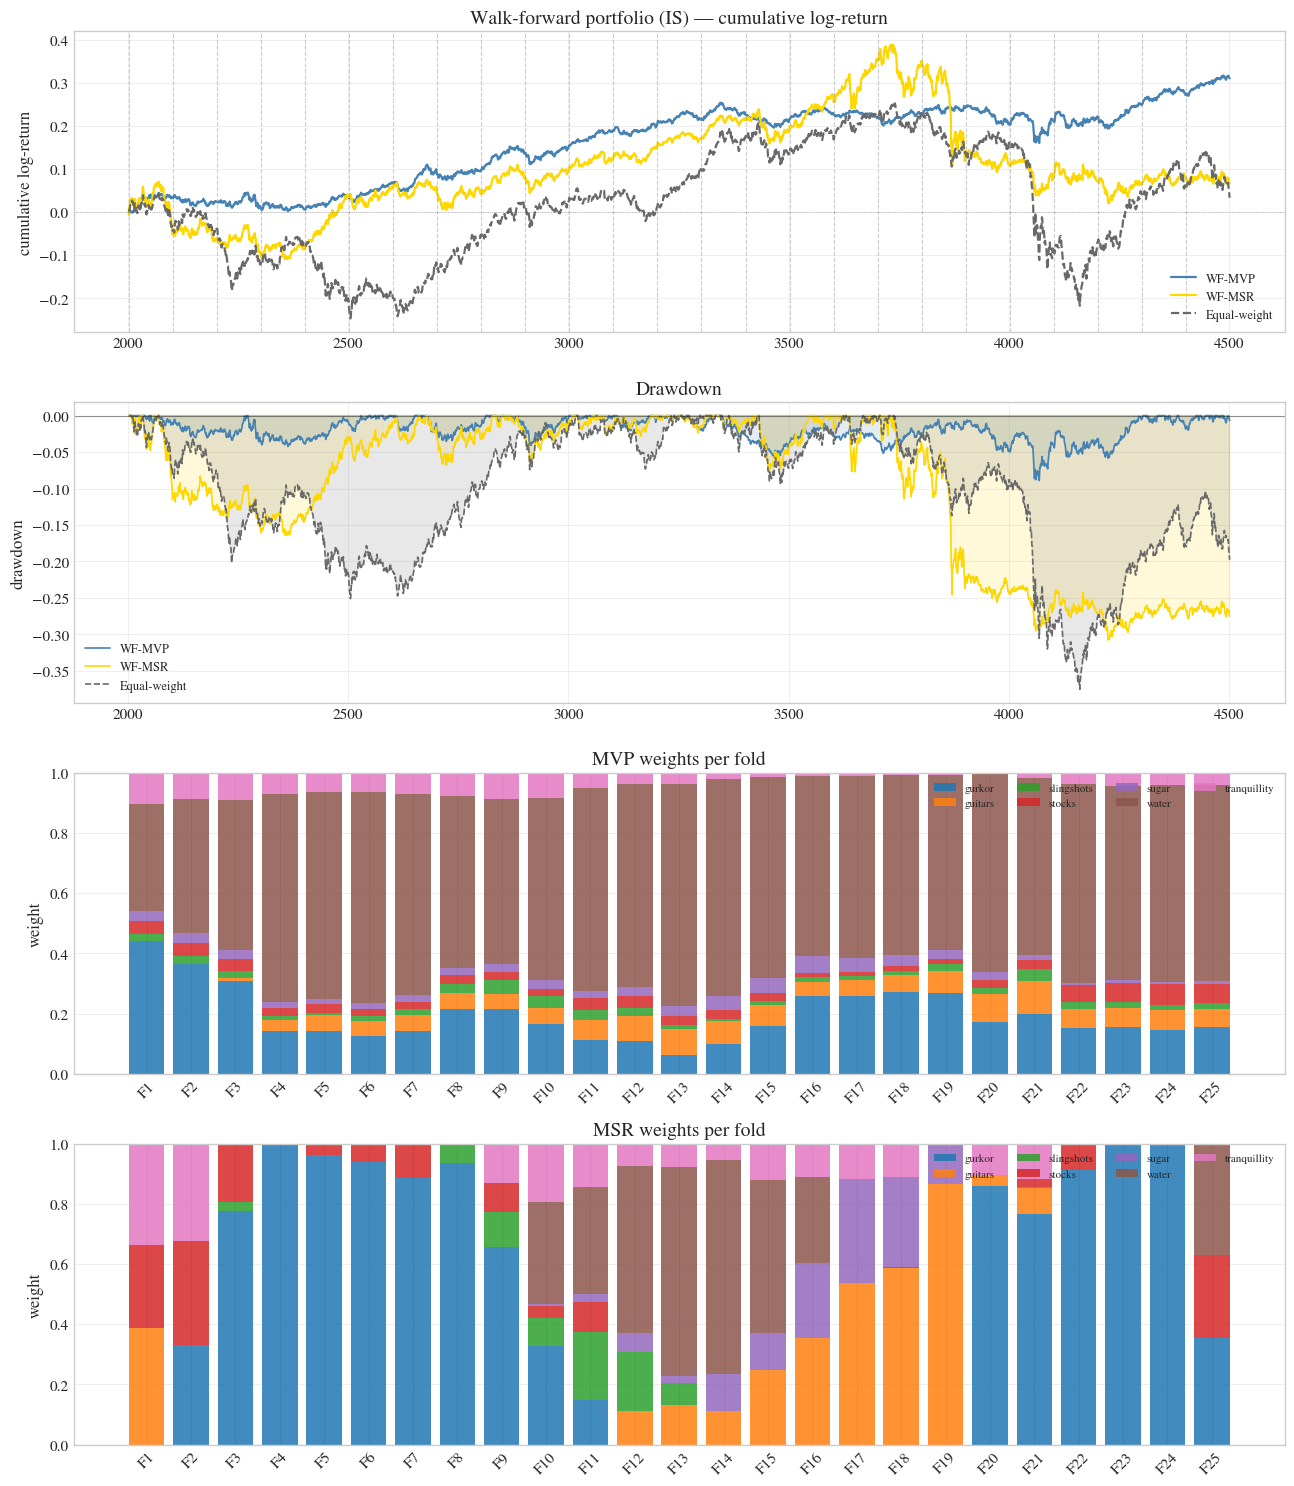

In [69]:
log_ret_is_wf = np.log(prices_is).diff().dropna()

def compute_mvp_weights(log_ret_window):
    Sig_w = log_ret_window.cov() * 365
    n     = len(log_ret_window.columns)
    def _vol(w): return float(np.sqrt(w @ Sig_w.values @ w))
    res = minimize(_vol, np.ones(n) / n, method="SLSQP",
                   bounds=[(0, 1)] * n,
                   constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return res.x if res.success else np.ones(n) / n

def compute_msr_weights(log_ret_window):
    mu_w  = log_ret_window.mean() * 365
    Sig_w = log_ret_window.cov()  * 365
    n     = len(log_ret_window.columns)
    def neg_sharpe(w):
        v = float(np.sqrt(w @ Sig_w.values @ w))
        r = float(w @ mu_w.values)
        return -(r - RF) / v if v > 1e-10 else 0.0
    res = minimize(neg_sharpe, np.ones(n) / n, method="SLSQP",
                   bounds=[(0, 1)] * n,
                   constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return res.x if res.success else np.ones(n) / n

def _port_sr(ret): v = ret.std() * np.sqrt(365); return (ret.mean() * 365 - RF) / v if v > 0 else np.nan

# ── sliding walk-forward — same IS_SIZE / OOS_SIZE / WF_STEP as other strategies
wf_chunks_mvp, wf_chunks_msr, wf_chunks_ew = [], [], []
fold_rows_mvp = []
n_lr = len(log_ret_is_wf)
fold = 0

while True:
    is_start = fold * WF_STEP
    is_end   = is_start + IS_SIZE
    oos_end  = is_end + OOS_SIZE
    if oos_end > n_lr:
        break
    lr_is  = log_ret_is_wf.iloc[is_start:is_end]
    lr_oos = log_ret_is_wf.iloc[is_end:oos_end]

    w_mvp = compute_mvp_weights(lr_is)
    w_msr = compute_msr_weights(lr_is)

    mvp_ret = lr_oos @ w_mvp
    msr_ret = lr_oos @ w_msr
    ew_ret  = lr_oos @ (np.ones(n_a) / n_a)

    wf_chunks_mvp.append(mvp_ret)
    wf_chunks_msr.append(msr_ret)
    wf_chunks_ew.append(ew_ret)
    fold_rows_mvp.append({
        "fold":        fold + 1,
        "OoS start":   lr_oos.index[0],
        "OoS end":     lr_oos.index[-1],
        "MVP IS SR":   round(float(_port_sr(lr_is @ w_mvp)), 3),
        "MSR IS SR":   round(float(_port_sr(lr_is @ w_msr)), 3),
        "MVP OoS SR":  round(float(_port_sr(mvp_ret)), 3),
        "MSR OoS SR":  round(float(_port_sr(msr_ret)), 3),
        "MVP weights": dict(zip(assets, w_mvp.round(3))),
        "MSR weights": dict(zip(assets, w_msr.round(3))),
    })
    fold += 1

wf_ret_mvp = pd.concat(wf_chunks_mvp)
wf_ret_msr = pd.concat(wf_chunks_msr)
wf_ret_ew  = pd.concat(wf_chunks_ew)
wf_sum_mvp = pd.DataFrame(fold_rows_mvp)

print(f"Portfolio walk-forward: {len(wf_sum_mvp)} folds  "
      f"({IS_SIZE}-day IS / {OOS_SIZE}-day OoS / {WF_STEP}-day step)")

# ── stitched OoS metrics ──────────────────────────────────────────────────────
print("\nWalk-forward stitched OoS metrics:")
for name, ret in [("WF-MVP", wf_ret_mvp), ("WF-MSR", wf_ret_msr), ("Equal-weight", wf_ret_ew)]:
    m = backtest_metrics(ret)
    print(f"  {name:<15}  SR={m['sharpe']:.3f}  vol={m['ann_vol']:.3f}  "
          f"maxDD={m['max_drawdown']:.3f}  calmar={m['calmar']:.3f}")

# ── bootstrap significance ────────────────────────────────────────────────────
print()
for name, ret in [("MVP", wf_ret_mvp), ("MSR", wf_ret_msr)]:
    sr_b, pval, ci = bootstrap_sr_pvalue(ret)
    print(f"  {name} bootstrap Sharpe: {sr_b:.3f}  p-val={pval:.3f}  90% CI={ci}")

# ── fold-level summary ────────────────────────────────────────────────────────
print("\nFold-level Sharpe:")
display(wf_sum_mvp[["fold", "OoS start", "OoS end", "MVP IS SR", "MSR IS SR", "MVP OoS SR", "MSR OoS SR"]])

# ── weight DataFrames ─────────────────────────────────────────────────────────
mvp_weight_df = pd.DataFrame(
    [fi["MVP weights"] for fi in fold_rows_mvp],
    index=[f"F{fi['fold']}" for fi in fold_rows_mvp],
)
msr_weight_df = pd.DataFrame(
    [fi["MSR weights"] for fi in fold_rows_mvp],
    index=[f"F{fi['fold']}" for fi in fold_rows_mvp],
)

# ── shared plot helper ────────────────────────────────────────────────────────
def plot_portfolio_wf(ret_specs, fold_sum, mvp_wdf, msr_wdf, title_prefix, save_path=None):
    fig, axes = plt.subplots(4, 1, figsize=(13, 15))

    for name, ret, c, ls in ret_specs:
        axes[0].plot(ret.cumsum().index, ret.cumsum().values,
                     color=c, linewidth=1.6, linestyle=ls, label=name)
    for i, (_, row) in enumerate(fold_sum.iterrows()):
        axes[0].axvline(row["OoS start"], color="black", linewidth=1.0, linestyle="--", alpha=0.5,
                        label="re-optimise" if i == 0 else None)
        axes[1].axvline(row["OoS start"], color="black", linewidth=1.0, linestyle="--", alpha=0.5)
    axes[0].axhline(0, color="black", linewidth=0.5, linestyle=":", alpha=0.4)
    axes[0].set_title(f"{title_prefix} — cumulative log-return")
    axes[0].set_ylabel("cumulative log-return")
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

    for name, ret, c, ls in ret_specs:
        equity = np.exp(ret.cumsum())
        dd = equity / equity.cummax() - 1
        axes[1].plot(dd.index, dd.values, color=c, linewidth=1.2, linestyle=ls, label=name)
        axes[1].fill_between(dd.index, dd.values, 0, where=(dd < 0), color=c, alpha=0.15)
    axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.4)
    axes[1].set_title("Drawdown"); axes[1].set_ylabel("drawdown")
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

    for ax, wdf, ptitle in [(axes[2], mvp_wdf, "MVP weights"), (axes[3], msr_wdf, "MSR weights")]:
        bottom = np.zeros(len(wdf))
        for a in assets:
            vals = wdf[a].values
            ax.bar(list(wdf.index), vals, bottom=bottom, color=asset_colors[a], label=a, alpha=0.85)
            bottom += vals
        ax.set_title(f"{ptitle} per fold"); ax.set_ylabel("weight"); ax.set_ylim(0, 1)
        ax.legend(fontsize=8, loc="upper right", ncol=4)
        ax.grid(True, alpha=0.3, axis="y")
        ax.tick_params(axis="x", labelrotation=45)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_portfolio_wf(
    [("WF-MVP", wf_ret_mvp, "steelblue", "-"),
     ("WF-MSR", wf_ret_msr, "gold",      "-"),
     ("Equal-weight", wf_ret_ew, "dimgray", "--")],
    wf_sum_mvp, mvp_weight_df, msr_weight_df,
    "Walk-forward portfolio (IS)", output / "mvp_walk_forward.png",
)


## 11. Real OoS Evaluation — Rolling Walk-Forward

The held-out OoS period is ~1127 days — far longer than a single 100-day fold.
Fixing the parameters found on the last IS fold and applying them for the full OoS would
contradict the rationale for sliding-window refitting: parameters go stale.

Instead we continue the exact same rolling scheme into the real OoS:

- IS window always looks back **500 days** from the start of the current OoS block, drawing from  data for early folds — no lookahead into future OoS
- OoS block: **100 days**  
- Window slides forward by **100 days** per fold (~11 folds over the real OoS)

This is what a live systematic trader would actually do: refit on a fixed lookback, evaluate the next period, repeat.

Real OoS: 752 days, starting at index 3004
Expected folds: 7
Running real OoS walk-forward for all strategies...
Done. (7 folds)
Portfolio real OoS: 7 folds  (500-day IS / 100-day OoS / 100-day step)

Real OoS stitched metrics:
  OoS-MVP          SR=1.521  vol=4.560  maxDD=-0.039  calmar=2.698
  OoS-MSR          SR=0.775  vol=5.180  maxDD=-0.035  calmar=2.083
  Equal-weight     SR=1.002  vol=10.610  maxDD=-0.134  calmar=1.089

  MVP bootstrap Sharpe: 1.522  p-val=0.019  90% CI=(np.float64(0.317), np.float64(2.773))
  MSR bootstrap Sharpe: 0.775  p-val=0.135  90% CI=(np.float64(-0.424), np.float64(1.997))

Fold-level OoS Sharpe:


,fold,OoS start,OoS end,MVP OoS SR,MSR OoS SR,EW OoS SR
0,1,4506,4604,1.629,0.398,2.873
1,2,4606,4704,-2.087,-1.544,1.802
2,3,4706,4804,2.834,0.807,-2.145
3,4,4806,4904,1.991,0.779,0.339
4,5,4906,5004,2.203,2.386,-0.770
5,6,5006,5104,1.107,0.517,1.729
6,7,5106,5204,3.243,2.801,4.824


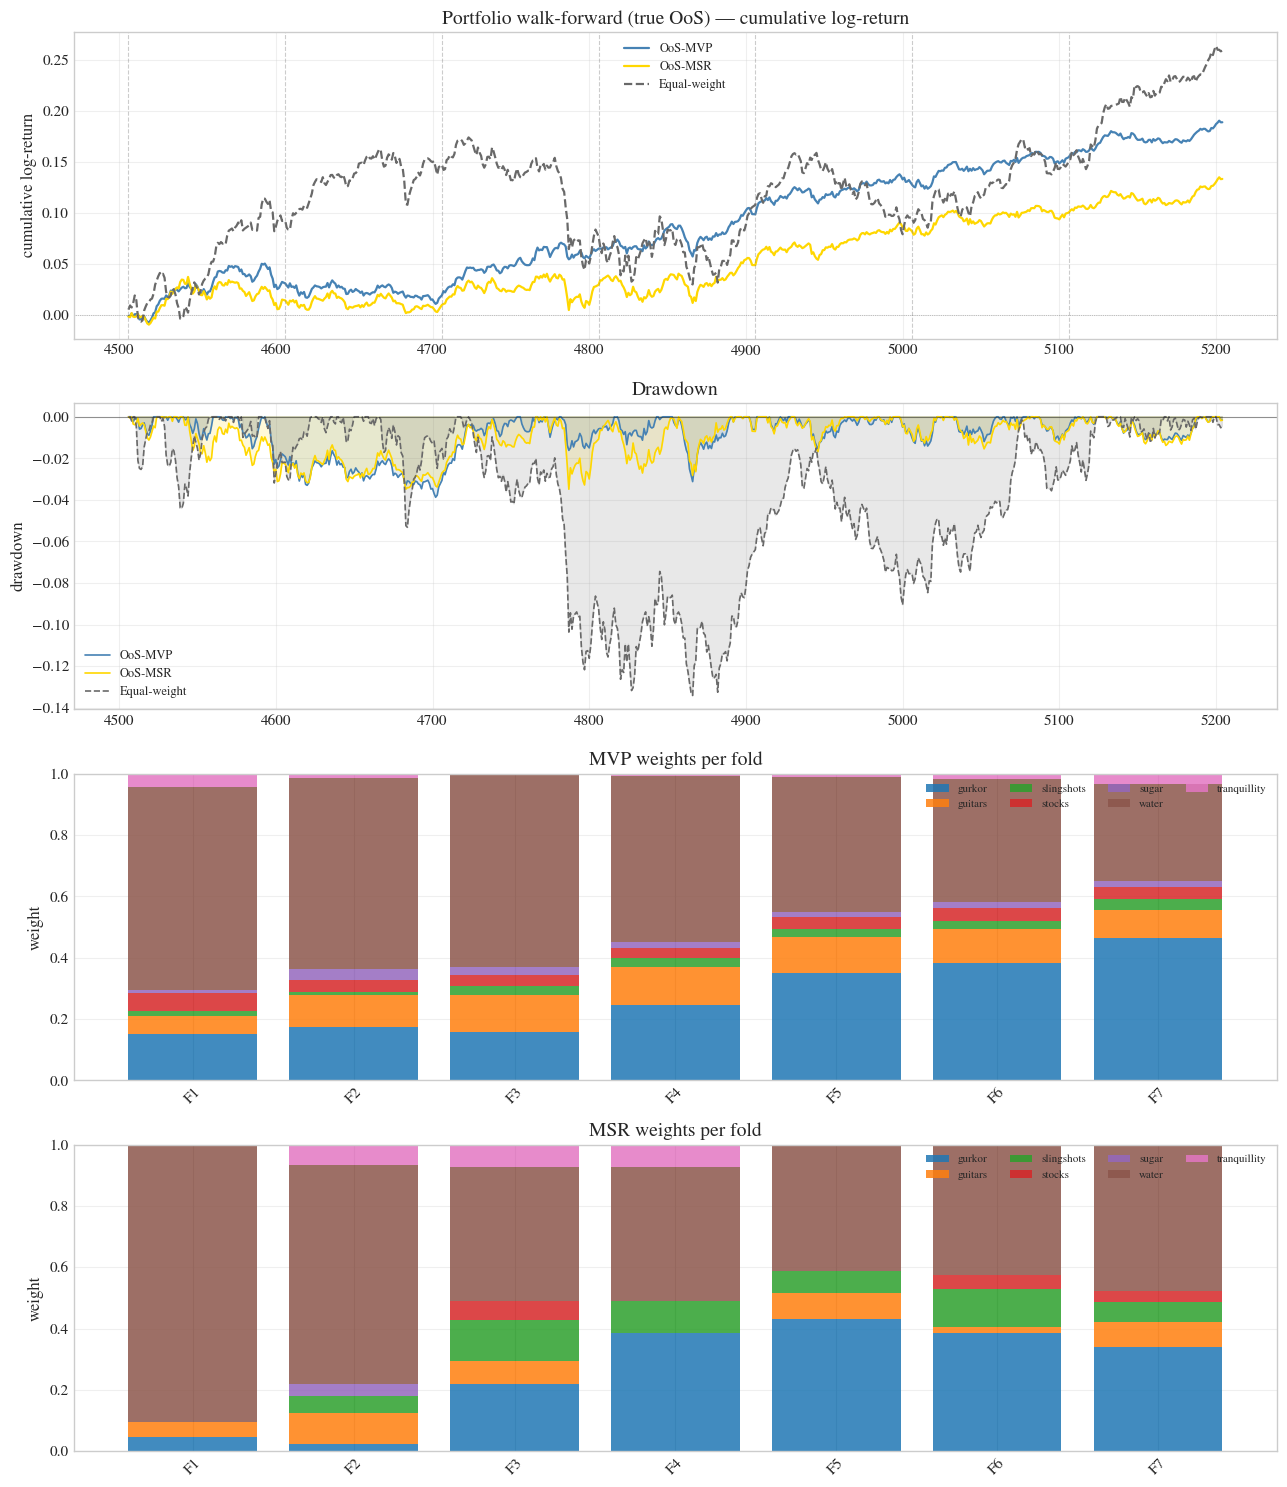

In [71]:
def walk_forward_real_oos(
    prices_all: pd.DataFrame,
    oos_start_idx: int,
    signal_fn,
    param_grid: list[dict],
    is_size: int = IS_SIZE,
    oos_size: int = OOS_SIZE,
    step: int = WF_STEP,
    ann: int = 365,
    per_asset: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Rolling walk-forward evaluation on the real OoS region.

    For fold k:
      IS  = prices_all[oos_start_idx - is_size + k*step : oos_start_idx + k*step]
      OoS = prices_all[oos_start_idx + k*step           : oos_start_idx + k*step + oos_size]

    The IS window slides forward with each fold, always using the most recent is_size days
    of already-elapsed data — no lookahead into future OoS blocks.
    """
    n = len(prices_all)
    oos_chunks, fold_rows = [], []

    fold = 0
    while True:
        is_start  = oos_start_idx - is_size + fold * step
        is_end    = oos_start_idx           + fold * step
        oos_end   = is_end + oos_size
        if is_start < 0 or oos_end > n:
            break
        p_is     = prices_all.iloc[is_start:is_end]
        p_oos    = prices_all.iloc[is_end:oos_end]
        combined = pd.concat([p_is, p_oos])

        if per_asset:
            best_p  = per_asset_grid_search(p_is, signal_fn, param_grid, ann=ann)
            sig     = build_per_asset_signal(combined, signal_fn, best_p)
            is_rets = apply_signal(
                build_per_asset_signal(p_is, signal_fn, best_p), p_is
            )["returns"]
            per_sr = []
            for col in is_rets.columns:
                r = is_rets[col].dropna()
                if (r == 0).all(): continue
                v = r.std() * np.sqrt(ann)
                per_sr.append(r.mean() * ann / v if v > 0 else np.nan)
            is_sr = float(np.nanmean(per_sr)) if per_sr else np.nan
        else:
            orig_types = {k: type(v) for k, v in param_grid[0].items()}
            param_cols = list(orig_types.keys())
            g        = grid_search(p_is, signal_fn, param_grid, ann=ann)
            best_row = g.loc[g["sharpe"].idxmax()]
            best_p   = {k: orig_types[k](best_row[k]) for k in param_cols}
            sig      = signal_fn(combined, **best_p)
            is_sr    = float(best_row["sharpe"])

        oos_ret_chunk = apply_signal(sig, combined)["returns"].loc[p_oos.index]
        port          = oos_ret_chunk.mean(axis=1)
        oos_ann_ret   = port.mean() * ann
        oos_equity    = np.exp(port.cumsum())
        oos_max_dd    = (oos_equity / oos_equity.cummax() - 1).min()

        base_row = {
            "fold": fold + 1, "IS days": len(p_is), "OoS days": len(p_oos),
            "OoS start": p_oos.index[0], "OoS end": p_oos.index[-1],
            "IS Sharpe":   round(float(is_sr), 3),
            "OoS ann_ret": round(oos_ann_ret, 4),
            "OoS max_dd":  round(oos_max_dd, 4),
        }
        if not per_asset:
            base_row.update({f"best {k}": best_p[k] for k in param_cols})
        fold_rows.append(base_row)
        oos_chunks.append(oos_ret_chunk)
        fold += 1

    return pd.concat(oos_chunks), pd.DataFrame(fold_rows)


prices_all    = pd.concat([prices_is, prices_oos])
oos_start_idx = len(prices_is)

print(f"Real OoS: {len(prices_oos)} days, starting at index {oos_start_idx}")
print(f"Expected folds: {len(prices_oos) // OOS_SIZE}")
print("Running real OoS walk-forward for all strategies...")

roos_returns,     roos_summary     = walk_forward_real_oos(prices_all, oos_start_idx, ma_crossover_signal, MA_PARAM_GRID,    per_asset=True)
roos_ret_gw,      roos_sum_gw      = walk_forward_real_oos(prices_all, oos_start_idx, gw_signal,           PAIRS_PARAM_GRID, per_asset=False)
roos_ret_gusl,    roos_sum_gusl    = walk_forward_real_oos(prices_all, oos_start_idx, gusl_signal,         PAIRS_PARAM_GRID, per_asset=False)
roos_ret_gw_ls,   roos_sum_gw_ls   = walk_forward_real_oos(prices_all, oos_start_idx, gw_ls_signal,        PAIRS_PARAM_GRID, per_asset=False)
roos_ret_gusl_ls, roos_sum_gusl_ls = walk_forward_real_oos(prices_all, oos_start_idx, gusl_ls_signal,      PAIRS_PARAM_GRID, per_asset=False)
roos_ret_ws,      roos_sum_ws      = walk_forward_real_oos(prices_all, oos_start_idx, ws_signal,           PAIRS_PARAM_GRID, per_asset=False)
roos_ret_ws_ls,   roos_sum_ws_ls   = walk_forward_real_oos(prices_all, oos_start_idx, ws_ls_signal,        PAIRS_PARAM_GRID, per_asset=False)
roos_ret_bh,      roos_sum_bh      = walk_forward_real_oos(prices_all, oos_start_idx, buy_and_hold_signal, [{}],             per_asset=False)
print(f"Done. ({len(roos_summary)} folds)")

# ── MVP + MSR real OoS walk-forward ──────────────────────────────────────────
roos_chunks_mvp, roos_chunks_msr, roos_chunks_ew = [], [], []
roos_rows_port = []
fold_port = 0
while True:
    is_start = oos_start_idx - IS_SIZE + fold_port * WF_STEP
    is_end   = oos_start_idx + fold_port * WF_STEP
    oos_end  = is_end + OOS_SIZE
    if is_start < 0 or oos_end > len(prices_all):
        break
    p_is  = prices_all.iloc[is_start:is_end]
    p_oos = prices_all.iloc[is_end:oos_end]
    lr_is  = np.log(p_is).diff().dropna()
    lr_oos = np.log(p_oos).diff().dropna()
    w_mvp = compute_mvp_weights(lr_is)
    w_msr = compute_msr_weights(lr_is)
    mvp_ret = lr_oos @ w_mvp
    msr_ret = lr_oos @ w_msr
    ew_ret  = lr_oos @ (np.ones(n_a) / n_a)
    roos_chunks_mvp.append(mvp_ret)
    roos_chunks_msr.append(msr_ret)
    roos_chunks_ew.append(ew_ret)
    roos_rows_port.append({
        "fold":        fold_port + 1,
        "OoS start":   lr_oos.index[0],
        "OoS end":     lr_oos.index[-1],
        "MVP OoS SR":  round(float(_port_sr(mvp_ret)), 3),
        "MSR OoS SR":  round(float(_port_sr(msr_ret)), 3),
        "EW OoS SR":   round(float(_port_sr(ew_ret)),  3),
        "MVP weights": dict(zip(assets, w_mvp.round(3))),
        "MSR weights": dict(zip(assets, w_msr.round(3))),
    })
    fold_port += 1

roos_ret_mvp_s = pd.concat(roos_chunks_mvp)
roos_ret_msr_s = pd.concat(roos_chunks_msr)
roos_ret_ew_s  = pd.concat(roos_chunks_ew)
roos_ret_mvp   = roos_ret_mvp_s.to_frame("portfolio")
roos_ret_msr   = roos_ret_msr_s.to_frame("portfolio")
roos_sum_mvp   = pd.DataFrame(roos_rows_port)
print(f"Portfolio real OoS: {len(roos_sum_mvp)} folds  "
      f"({IS_SIZE}-day IS / {OOS_SIZE}-day OoS / {WF_STEP}-day step)")

# ── stitched OoS metrics ──────────────────────────────────────────────────────
print("\nReal OoS stitched metrics:")
for name, ret in [("OoS-MVP", roos_ret_mvp_s), ("OoS-MSR", roos_ret_msr_s), ("Equal-weight", roos_ret_ew_s)]:
    m = backtest_metrics(ret)
    print(f"  {name:<15}  SR={m['sharpe']:.3f}  vol={m['ann_vol']:.3f}  "
          f"maxDD={m['max_drawdown']:.3f}  calmar={m['calmar']:.3f}")

# ── bootstrap significance ────────────────────────────────────────────────────
print()
for name, ret in [("MVP", roos_ret_mvp_s), ("MSR", roos_ret_msr_s)]:
    sr_b, pval, ci = bootstrap_sr_pvalue(ret)
    print(f"  {name} bootstrap Sharpe: {sr_b:.3f}  p-val={pval:.3f}  90% CI={ci}")

# ── fold-level summary ────────────────────────────────────────────────────────
print("\nFold-level OoS Sharpe:")
display(roos_sum_mvp[["fold", "OoS start", "OoS end", "MVP OoS SR", "MSR OoS SR", "EW OoS SR"]])

# ── real OoS plot (identical layout to IS plot) ───────────────────────────────
roos_mvp_wdf = pd.DataFrame(
    [r["MVP weights"] for r in roos_rows_port],
    index=[f"F{r['fold']}" for r in roos_rows_port],
)
roos_msr_wdf = pd.DataFrame(
    [r["MSR weights"] for r in roos_rows_port],
    index=[f"F{r['fold']}" for r in roos_rows_port],
)
plot_portfolio_wf(
    [("OoS-MVP",      roos_ret_mvp_s, "steelblue", "-"),
     ("OoS-MSR",      roos_ret_msr_s, "gold",      "-"),
     ("Equal-weight", roos_ret_ew_s,  "dimgray",   "--")],
    roos_sum_mvp, roos_mvp_wdf, roos_msr_wdf,
    "Portfolio walk-forward (true OoS)", output / "mvp_real_oos.png",
)

roos_specs = [
    ("MA crossover",   roos_returns,     roos_summary),
    ("Pairs g/w",      roos_ret_gw,      roos_sum_gw),
    ("Pairs gu/sl",    roos_ret_gusl,    roos_sum_gusl),
    ("Pairs w/sl",     roos_ret_ws,      roos_sum_ws),
    ("Pairs g/w LS",   roos_ret_gw_ls,   roos_sum_gw_ls),
    ("Pairs gu/sl LS", roos_ret_gusl_ls, roos_sum_gusl_ls),
    ("Pairs w/sl LS",  roos_ret_ws_ls,   roos_sum_ws_ls),
    ("Buy & Hold",     roos_ret_bh,      roos_sum_bh),
    ("MVP",            roos_ret_mvp,     roos_sum_mvp),
    ("MSR",            roos_ret_msr,     roos_sum_mvp),
]

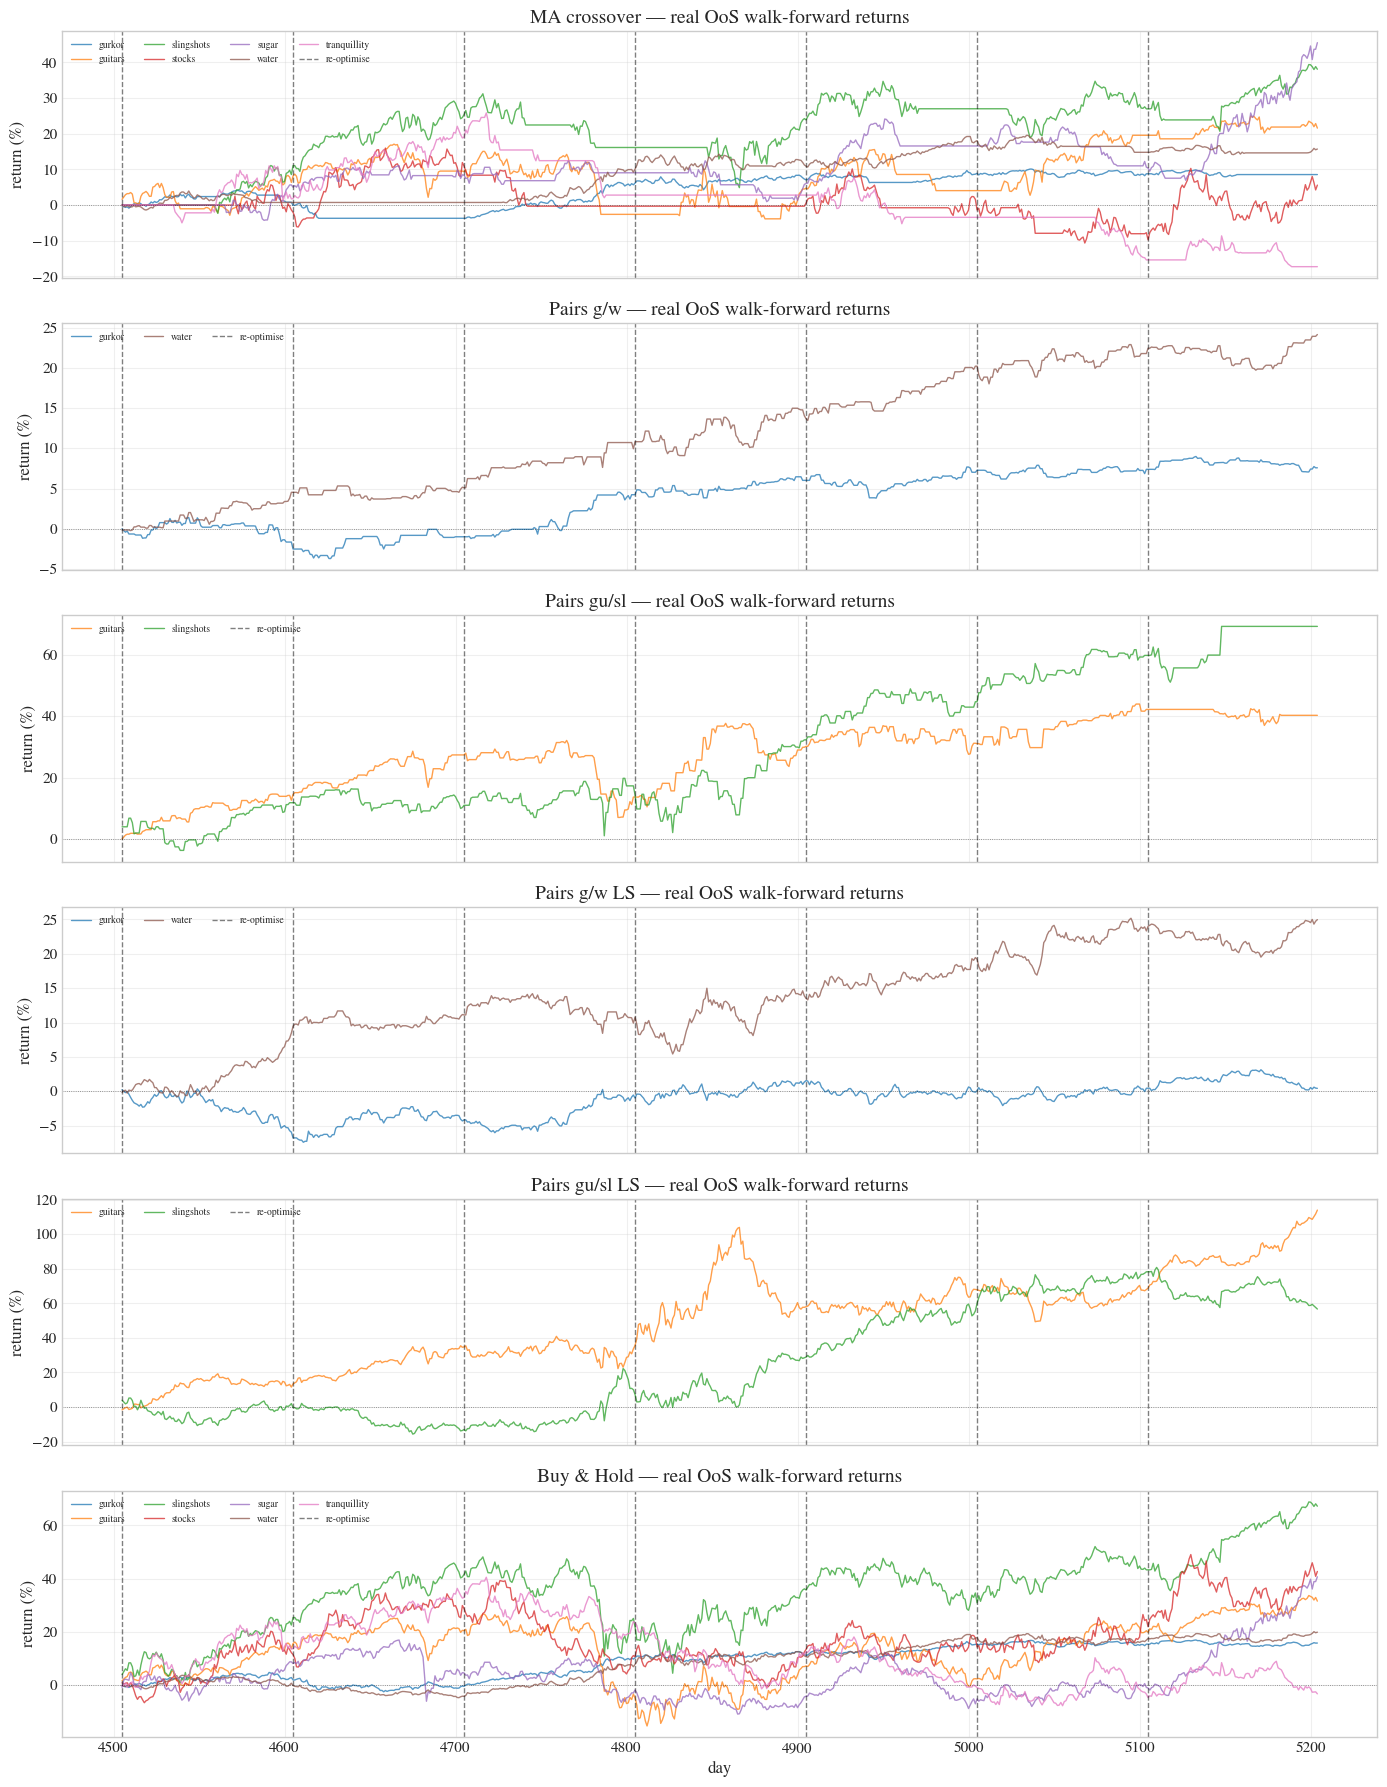

In [41]:
# ── Cumulative returns: real OoS walk-forward, per strategy ──────────────────
n_strats = len(roos_specs)
fig, axes = plt.subplots(n_strats, 1, figsize=(14, 3 * n_strats), sharex=True)

if n_strats == 1:
    axes = [axes]

for ax_eq, (label, roos_ret, roos_sum) in zip(axes, roos_specs):
    for col in roos_ret.columns:
        ret = roos_ret[col]
        if (ret == 0).all():
            continue
        color = asset_colors.get(col, "gray")

        log_cum = ret.cumsum()
        padded  = pd.concat([pd.Series([0.0], index=[log_cum.index[0] - 1]), log_cum])
        equity  = (np.exp(padded).iloc[1:] - 1) * 100
        ax_eq.plot(equity.index, equity.values, linewidth=1.0, alpha=0.75,
                   color=color, label=col)

    for i, (_, row) in enumerate(roos_sum.iterrows()):
        ax_eq.axvline(row["OoS start"], color="black", linewidth=1.0,
                      linestyle="--", alpha=0.5,
                      label="re-optimise" if i == 0 else None)

    ax_eq.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
    ax_eq.set_title(f"{label} — real OoS walk-forward returns")
    ax_eq.set_ylabel("return (%)")
    ax_eq.legend(fontsize=7, ncol=4, loc="upper left")
    ax_eq.grid(True, alpha=0.3)

axes[-1].set_xlabel("day")

plt.tight_layout()
plt.savefig(output / "real_oos_walk_forward.png", bbox_inches="tight")
plt.show()




In [42]:
# ── Per-(strategy, asset) metrics — real OoS ────────────────────────────────
rows_roos = []
for label, roos_ret, roos_sum in roos_specs:
    for asset in roos_ret.columns:
        ret = roos_ret[asset]
        if (ret == 0).all():
            continue

        positive_sharpe_folds = 0
        for _, row in roos_sum.iterrows():
            fold_ret = roos_ret[asset].loc[row["OoS start"]:row["OoS end"]].dropna()
            if (fold_ret == 0).all():
                continue
            v = fold_ret.std() * np.sqrt(365)
            sr = (fold_ret.mean() * 365 - RF) / v if v > 0 else np.nan
            if pd.notna(sr) and sr > 0:
                positive_sharpe_folds += 1

        bh_asset = roos_ret_bh[asset] if asset in roos_ret_bh.columns else None
        m = backtest_metrics(ret, bh_ret=bh_asset)

        rows_roos.append({
            "Strategy": label,
            "Asset": asset,
            "positive_sharpe_folds": positive_sharpe_folds / len(roos_sum),
            **{k: round(v, 3) if isinstance(v, float) else v for k, v in m.items()}
        })

roos_metrics_df = pd.DataFrame(rows_roos).set_index(["Strategy", "Asset"])
roos_metrics_df["excess_sharpe"] = roos_metrics_df["sharpe"] - roos_metrics_df["bh_sharpe"]
roos_metrics_df["excess_ret"]    = roos_metrics_df["excess_ret"] * 100

print("Real OoS walk-forward — per (strategy, asset) metrics:")
display(roos_metrics_df[METRIC_COLS].drop("Buy & Hold", level=0))
roos_metrics_df[METRIC_COLS].drop("Buy & Hold", level=0).reset_index().to_latex(
    output / "real_oos_metrics_per_asset.tex", index=False, float_format="%.2f"
)


Real OoS walk-forward — per (strategy, asset) metrics:


ann_return   cagr  excess_riskfree  excess_ret  \
Strategy       Asset                                                          
MA crossover   gurkor              4.28   4.37            0.014        -3.6   
               guitars            10.19  10.73            0.077        -4.6   
               slingshots         16.83  18.33            0.153       -12.4   
               stocks              2.84   2.88           -0.001       -17.5   
               sugar              19.57  21.62            0.186         2.2   
               water               7.61   7.91            0.049        -2.0   
               tranquillity       -9.90  -9.42           -0.124        -7.7   
Pairs g/w      gurkor              3.81   3.88            0.009        -4.1   
               water              11.27  11.93            0.089         2.0   
Pairs gu/sl    guitars            17.65  19.30            0.163         3.9   
               slingshots         27.44  31.57            0.286         0.8   
Pairs g/w LS   gurkor              0.23   0.23           -0.028        -7.7   
               water              11.62  12.32            0.093         2.4   
Pairs gu/sl LS guitars            39.65  48.67            0.457        33.3   
               slingshots         23.42  26.40            0.234        -4.3   

                             ann_vol  sharpe  bh_sharpe  max_drawdown  \
Strategy       Asset                                                    
MA crossover   gurkor           5.69   0.225      0.701        -0.075   
               guitars         19.61   0.367      0.415        -0.179   
               slingshots      19.11   0.724      0.800        -0.201   
               stocks          21.58  -0.008      0.543        -0.230   
               sugar           15.23   1.088      0.626        -0.138   
               water            7.20   0.641      0.783        -0.045   
               tranquillity    16.86  -0.765     -0.190        -0.343   
Pairs g/w      gurkor           4.51   0.179      0.701        -0.050   
               water            5.82   1.421      0.783        -0.033   
Pairs gu/sl    guitars         17.62   0.831      0.415        -0.190   
               slingshots      23.27   1.050      0.800        -0.149   
Pairs g/w LS   gurkor           6.19  -0.448      0.701        -0.077   
               water            7.97   1.081      0.783        -0.077   
Pairs gu/sl LS guitars         27.16   1.350      0.415        -0.268   
               slingshots      29.76   0.686      0.800        -0.198   

                             trades_per_year  avg_hold_days  \
Strategy       Asset                                          
MA crossover   gurkor                   14.6           17.5   
               guitars                   8.9           28.8   
               slingshots               13.0           18.2   
               stocks                    4.2           47.6   
               sugar                    22.4            8.1   
               water                     8.3           28.1   
               tranquillity              7.3           22.0   
Pairs g/w      gurkor                   87.6            1.9   
               water                    89.2            1.8   
Pairs gu/sl    guitars                  93.3            1.9   
               slingshots               93.3            1.7   
Pairs g/w LS   gurkor                   33.9            9.5   
               water                    26.1           12.6   
Pairs gu/sl LS guitars                   3.7           98.7   
               slingshots               14.6           24.0   

                             positive_sharpe_folds  
Strategy       Asset                                
MA crossover   gurkor                     0.428571  
               guitars                    0.714286  
               slingshots                 0.714286  
               stocks                     0.428571  
               sugar                      0.571429  
